<a href="https://colab.research.google.com/github/nalenndra/CfDS/blob/Project/KaburAjaDulu_Mahardi_Nalendra_Syafa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Navigating The Phenomenon Of Work Abroad Through Public Perspectives On Social Media X Hashtag "KaburAjaDulu” with Deep Learning Sentiment and Social Network Analysis
Mahardi Nalendra Syafa \\
Data Scientist Intern \\
Center for Digital Society \\

# Data

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
import pandas as pd
import os

# Tentukan path ke folder yang berisi file CSV
folder_path = '/content/drive/MyDrive/File kuliah/CfDS/Laporan Akhir/Data_Tweet/'

# Dapatkan daftar semua file CSV di folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Buat list kosong untuk menyimpan semua DataFrame
all_data = []

# Loop melalui setiap file CSV dan baca isinya, kemudian tambahkan ke list
for csv_file in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    try:
        data = pd.read_csv(file_path)
        all_data.append(data)  # Tambahkan DataFrame ke list
        print(f"Memproses file: {csv_file}")
    except pd.errors.EmptyDataError:
        print(f"File kosong, dilewati: {csv_file}")
    except Exception as e:
        print(f"Error saat memproses file {csv_file}: {e}")

# Gabungkan semua DataFrame dalam list menjadi satu DataFrame
combined_data = pd.concat(all_data, ignore_index=True)

# Sekarang 'combined_data' berisi semua data dari semua file CSV
print(combined_data.head())  # Menampilkan 5 baris pertama data gabungan

File kosong, dilewati: kaburajadulu_2024-09-03_to_2024-09-04.csv
Memproses file: kaburajadulu_2024-09-04_to_2024-09-07.csv
File kosong, dilewati: kaburajadulu_2024-09-07_to_2024-09-10.csv
Memproses file: kaburajadulu_2024-09-16_to_2024-09-19.csv
Memproses file: kaburajadulu_2024-09-22_to_2024-09-25.csv
Memproses file: kaburajadulu_2024-08-04_to_2024-08-07.csv
File kosong, dilewati: kaburajadulu_2024-08-07_to_2024-08-10.csv
Memproses file: kaburajadulu_2024-08-13_to_2024-08-16.csv
Memproses file: kaburajadulu_2024-08-16_to_2024-08-19.csv
File kosong, dilewati: kaburajadulu_2024-08-19_to_2024-08-22.csv
File kosong, dilewati: kaburajadulu_2024-08-22_to_2024-08-25.csv
File kosong, dilewati: kaburajadulu_2024-07-04_to_2024-07-07.csv
File kosong, dilewati: kaburajadulu_2024-07-01_to_2024-07-04.csv
Memproses file: kaburajadulu_2024-07-07_to_2024-07-10.csv
File kosong, dilewati: kaburajadulu_2024-07-10_to_2024-07-13.csv
File kosong, dilewati: kaburajadulu_2024-07-13_to_2024-07-16.csv
File koso

In [33]:
combined_data.info() #created_at

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      100 non-null    int64 
 1   created_at               100 non-null    object
 2   favorite_count           100 non-null    int64 
 3   full_text                100 non-null    object
 4   id_str                   100 non-null    int64 
 5   image_url                11 non-null     object
 6   in_reply_to_screen_name  32 non-null     object
 7   lang                     100 non-null    object
 8   location                 81 non-null     object
 9   quote_count              100 non-null    int64 
 10  reply_count              100 non-null    int64 
 11  retweet_count            100 non-null    int64 
 12  tweet_url                100 non-null    object
 13  user_id_str              100 non-null    int64 
 14  username                 100 non-null    ob

In [5]:
#show data with conversation_id_str = 1824777107328880642
combined_data[combined_data['conversation_id_str'] == 1824777107328880642]

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
63,1824777107328880642,Sat Aug 17 11:55:39 +0000 2024,1153,Nggak berasa udah mau 2 th gw kerja dan tingga...,1824777107328880642,https://pbs.twimg.com/media/GVLjrzfagAA8TqN.jpg,NaN,in,"Tokyo-to, Japan",11,6,120,https://x.com/adith_wp/status/1824777107328880642,246398684,adith_wp
73,1824777107328880642,Sat Aug 17 11:55:44 +0000 2024,10,Kalo kalian tertarik ke Jepang South Korea ata...,1824777125637091339,NaN,adith_wp,in,"Tokyo-to, Japan",0,1,0,https://x.com/adith_wp/status/1824777125637091339,246398684,adith_wp
74,1824777107328880642,Sat Aug 17 11:55:41 +0000 2024,6,Beneran deh yg kebayang soal kerja di luar neg...,1824777112903184502,NaN,adith_wp,in,"Tokyo-to, Japan",0,1,0,https://x.com/adith_wp/status/1824777112903184502,246398684,adith_wp
75,1824777107328880642,Sat Aug 17 11:55:43 +0000 2024,2,Nah ini cerita dengan modal gw. Gimana kalo ka...,1824777123355361461,NaN,adith_wp,in,"Tokyo-to, Japan",0,1,0,https://x.com/adith_wp/status/1824777123355361461,246398684,adith_wp
77,1824777107328880642,Sat Aug 17 11:55:42 +0000 2024,5,Beruntung di 2022 bbrp recruiter company Jepan...,1824777120725529021,NaN,adith_wp,in,"Tokyo-to, Japan",0,1,0,https://x.com/adith_wp/status/1824777120725529021,246398684,adith_wp


duplikasi conv id bukan beriarti tweet sama

## Data apify

In [34]:
import pandas as pd
import os

# Tentukan path ke folder yang berisi file CSV
folder_path = '/content/drive/MyDrive/File kuliah/CfDS/Laporan Akhir/Easy_twitter_apify/'

# Dapatkan daftar semua file CSV di folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Buat list kosong untuk menyimpan semua DataFrame
all_data = []

# Loop melalui setiap file CSV dan baca isinya, kemudian tambahkan ke list
for csv_file in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    try:
        data = pd.read_csv(file_path)
        all_data.append(data)  # Tambahkan DataFrame ke list
        print(f"Memproses file: {csv_file}")
    except pd.errors.EmptyDataError:
        print(f"File kosong, dilewati: {csv_file}")
    except Exception as e:
        print(f"Error saat memproses file {csv_file}: {e}")

# Gabungkan semua DataFrame dalam list menjadi satu DataFrame
combined_data_apify = pd.concat(all_data, ignore_index=True)

# Sekarang 'combined_data' berisi semua data dari semua file CSV
print(combined_data_apify.head())  # Menampilkan 5 baris pertama data gabungan

Memproses file: dataset_tweet-scraper_2024-10-21_07-32-46-594.csv
Memproses file: dataset_tweet-scraper_2024-10-21_07-36-37-123.csv
Memproses file: dataset_easy-twitter-search-scraper_2024-10-27_15-12-56-266.csv
Memproses file: dataset_easy-twitter-search-scraper_2024-10-27_15-24-09-903.csv
Memproses file: dataset_easy-twitter-search-scraper_2024-10-27_15-32-41-358.csv
Memproses file: dataset_easy-twitter-search-scraper_2024-10-27_15-39-09-405.csv
Memproses file: dataset_easy-twitter-search-scraper_2024-10-27_15-39-09-405 (1).csv
  author/canDm author/canMediaTag  \
0         True              False   
1         True              False   
2         True              False   
3         True              False   
4         True              False   

                                          author/coverPicture  \
0   https://pbs.twimg.com/profile_banners/94275536/1392723086   
1   https://pbs.twimg.com/profile_banners/69194832/1600771262   
2   https://pbs.twimg.com/profile_banners/8292

In [35]:
combined_data_apify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Columns: 307 entries, author/canDm to quotedTweet/links/5
dtypes: bool(2), float64(131), int64(1), object(173)
memory usage: 1.4+ MB


In [36]:
#'/content/drive/MyDrive/File kuliah/CfDS/Laporan Akhir/New_apify'
import pandas as pd
import os

# Tentukan path ke folder yang berisi file CSV
folder_path = '/content/drive/MyDrive/File kuliah/CfDS/Laporan Akhir/New_apify/'

# Dapatkan daftar semua file CSV di folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Buat list kosong untuk menyimpan semua DataFrame
all_data = []

# Loop melalui setiap file CSV dan baca isinya, kemudian tambahkan ke list
for csv_file in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    try:
        data = pd.read_csv(file_path)
        all_data.append(data)  # Tambahkan DataFrame ke list
        print(f"Memproses file: {csv_file}")
    except pd.errors.EmptyDataError:
        print(f"File kosong, dilewati: {csv_file}")
    except Exception as e:
        print(f"Error saat memproses file {csv_file}: {e}")

# Gabungkan semua DataFrame dalam list menjadi satu DataFrame
combined_data_apify_new = pd.concat(all_data, ignore_index=True)

# Sekarang 'combined_data' berisi semua data dari semua file CSV
print(combined_data_apify_new.head())  # Menampilkan 5 baris pertama data gabungan

Memproses file: dataset_easy-twitter-search-scraper_2024-10-29_11-55-18-299_20reply.csv
Memproses file: dataset_easy-twitter-search-scraper_2024-10-29_12-16-39-568_2023_20 reply.csv
  avatar fullname                   id  \
0    NaN      NaN  1850490485351256364   
1    NaN      NaN  1834505771159056640   
2    NaN      NaN  1850545176000782613   
3    NaN      NaN  1850529792598438177   
4    NaN      NaN  1850542393227120914   

                                                                 images/0  \
0                                                                     NaN   
1  https://cdn.xcancel.comhttps://pbs.twimg.com/media/GXV18E2XEAAqHeH.jpg   
2                                                                     NaN   
3                                                                     NaN   
4                                                                     NaN   

  images/1 images/2 images/3 isMainTweet isPinned  isQuote isReply  isRetweet  \
0      NaN      NaN  

In [37]:
# concat combined_data_apify_new and combined_data_apify
combined_data_apify = pd.concat([combined_data_apify, combined_data_apify_new], ignore_index=True)

In [44]:
# pandas display max column width
pd.set_option('display.max_colwidth', None)
#display all column
pd.set_option('display.max_columns', None)

In [55]:
combined_data_apify.head()

,author/canDm,author/canMediaTag,author/coverPicture,author/createdAt,author/description,author/entities/url/urls/0/display_url,author/entities/url/urls/0/expanded_url,author/entities/url/urls/0/indices/0,author/entities/url/urls/0/indices/1,author/entities/url/urls/0/url,author/fastFollowersCount,author/favouritesCount,author/followers,author/following,author/hasCustomTimelines,author/id,author/isBlueVerified,author/isTranslator,author/isVerified,author/location,author/mediaCount,author/name,author/pinnedTweetIds/0,author/possiblySensitive,author/profilePicture,author/status,author/statusesCount,author/twitterUrl,author/type,author/url,author/userName,bookmarkCount,conversationId,createdAt,entities/hashtags/0/indices/0,entities/hashtags/0/indices/1,entities/hashtags/0/text,entities/media/0/display_url,entities/media/0/expanded_url,entities/media/0/ext_alt_text,entities/media/0/ext_media_availability/status,entities/media/0/id_str,entities/media/0/indices/0,entities/media/0/indices/1,entities/media/0/media_key,entities/media/0/media_results/result/media_key,entities/media/0/media_url_https,entities/media/0/original_info/focus_rects/0/h,entities/media/0/original_info/focus_rects/0/w,entities/media/0/original_info/focus_rects/0/x,entities/media/0/original_info/focus_rects/0/y,entities/media/0/original_info/focus_rects/1/h,entities/media/0/original_info/focus_rects/1/w,entities/media/0/original_info/focus_rects/1/x,entities/media/0/original_info/focus_rects/1/y,entities/media/0/original_info/focus_rects/2/h,entities/media/0/original_info/focus_rects/2/w,entities/media/0/original_info/focus_rects/2/x,entities/media/0/original_info/focus_rects/2/y,entities/media/0/original_info/focus_rects/3/h,entities/media/0/original_info/focus_rects/3/w,entities/media/0/original_info/focus_rects/3/x,entities/media/0/original_info/focus_rects/3/y,entities/media/0/original_info/focus_rects/4/h,entities/media/0/original_info/focus_rects/4/w,entities/media/0/original_info/focus_rects/4/x,entities/media/0/original_info/focus_rects/4/y,entities/media/0/original_info/height,entities/media/0/original_info/width,entities/media/0/sizes/large/h,entities/media/0/sizes/large/resize,entities/media/0/sizes/large/w,entities/media/0/sizes/medium/h,entities/media/0/sizes/medium/resize,entities/media/0/sizes/medium/w,entities/media/0/sizes/small/h,entities/media/0/sizes/small/resize,entities/media/0/sizes/small/w,entities/media/0/sizes/thumb/h,entities/media/0/sizes/thumb/resize,entities/media/0/sizes/thumb/w,entities/media/0/type,entities/media/0/url,entities/user_mentions/0/id_str,entities/user_mentions/0/indices/0,entities/user_mentions/0/indices/1,entities/user_mentions/0/name,entities/user_mentions/0/screen_name,entities/user_mentions/1/id_str,entities/user_mentions/1/indices/0,entities/user_mentions/1/indices/1,entities/user_mentions/1/name,entities/user_mentions/1/screen_name,entities/user_mentions/2/id_str,entities/user_mentions/2/indices/0,entities/user_mentions/2/indices/1,entities/user_mentions/2/name,entities/user_mentions/2/screen_name,extendedEntities/media/0/display_url,extendedEntities/media/0/expanded_url,extendedEntities/media/0/ext_alt_text,extendedEntities/media/0/ext_media_availability/status,extendedEntities/media/0/id_str,extendedEntities/media/0/indices/0,extendedEntities/media/0/indices/1,extendedEntities/media/0/media_key,extendedEntities/media/0/media_results/result/media_key,extendedEntities/media/0/media_url_https,extendedEntities/media/0/original_info/focus_rects/0/h,extendedEntities/media/0/original_info/focus_rects/0/w,extendedEntities/media/0/original_info/focus_rects/0/x,extendedEntities/media/0/original_info/focus_rects/0/y,extendedEntities/media/0/original_info/focus_rects/1/h,extendedEntities/media/0/original_info/focus_rects/1/w,extendedEntities/media/0/original_info/focus_rects/1/x,extendedEntities/media/0/original_info/focus_rects/1/y,extendedEntities/media/0/original_info/focus_rects/2/h,extendedEntities/media/0/original_in

In [52]:
combined_data_apify['timestamp'].head()

,timestamp
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [53]:
combined_data_apify_new['timestamp'].head()

,timestamp
0,2024-10-27T10:51:00.000Z
1,2024-09-13T08:13:00.000Z
2,2024-10-27T14:28:00.000Z
3,2024-10-27T13:27:00.000Z
4,2024-10-27T14:17:00.000Z


In [48]:
combined_data_apify_new.head()

,avatar,fullname,id,images/0,images/1,images/2,images/3,isMainTweet,isPinned,isQuote,isReply,isRetweet,isRootThread,likes,links/0,links/1,links/2,mainTweetUrl,quotedTweet/avatar,quotedTweet/fullname,quotedTweet/images/0,quotedTweet/images/1,quotedTweet/images/2,quotedTweet/images/3,quotedTweet/links/0,quotedTweet/links/1,quotedTweet/links/2,quotedTweet/links/3,quotedTweet/links/4,quotedTweet/links/5,quotedTweet/text,quotedTweet/timestamp,quotedTweet/url,quotedTweet/username,quotes,replies,replyToTweet/avatar,replyToTweet/fullname,replyToTweet/id,replyToTweet/images/0,replyToTweet/images/1,replyToTweet/images/2,replyToTweet/images/3,replyToTweet/isMainTweet,replyToTweet/isPinned,replyToTweet/isQuote,replyToTweet/isRetweet,replyToTweet/likes,replyToTweet/links/0,replyToTweet/links/1,replyToTweet/mainTweetUrl,replyToTweet/quotedTweet/avatar,replyToTweet/quotedTweet/fullname,replyToTweet/quotedTweet/images/0,replyToTweet/quotedTweet/images/1,replyToTweet/quotedTweet/images/2,replyToTweet/quotedTweet/images/3,replyToTweet/quotedTweet/links/0,replyToTweet/quotedTweet/links/1,replyToTweet/quotedTweet/text,replyToTweet/quotedTweet/timestamp,replyToTweet/quotedTweet/url,replyToTweet/quotedTweet/username,replyToTweet/quotes,replyToTweet/replies,replyToTweet/retweets,replyToTweet/searchQuery,replyToTweet/text,replyToTweet/timestamp,replyToTweet/url,replyToTweet/username,replyToTweet/verified,replyingTo/0,replyingTo/1,retweets,searchQuery,text,timestamp,url,user/avatar,user/description,user/joinDate,user/location,user/totalFollowers,user/totalFollowing,user/totalLikes,user/totalTweets,user/url,user/userFullName,user/username,user/verified,user/website,username,verified,links/3,links/4,links/5,replyingTo/2
0,NaN,NaN,1850490485351256364,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,NaN,706,https://twitter.com/search?q=%23KaburAjaDulu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,#kaburajadulu,"Mungkin bisa jadi pertimbangan buat temen-temen yang tertarik untuk #KaburAjaDulu: mulai fokus belajar bahasa asing yang native speaker-nya jarang bisa berbahasa Inggris. Kalau udah fluent bahasa tsb + fluent EN juga, kesempatan untuk diliriknya makin besar.",2024-10-27T10:51:00.000Z,https://twitter.com/sisthaaaaa/status/1850490485351256364,https://cdn.xcancel.comhttps://pbs.twimg.com/profile_images/1806549167067787264/eMBH4lRO.jpg,"Indonesian lives in Japan｜iPhone photography｜all pictures edited on Lightroom Mobile｜tweet in ID, EN, JP",2009-07-31T03:49:00.000Z,"Tokyo-to, Japan",26099,515,2494,55856,https://twitter.com//sisthaaaaa,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,NaN,False,NaN,NaN,NaN,NaN
1,NaN,NaN,1834505771159056640,https://cdn.xcancel.comhttps://pbs.twimg.com/media/GXV18E2XEAAqHeH.jpg,NaN,NaN,NaN,NaN,NaN,False,False,True,NaN,7373,https://twitter.com/search?q=%23kaburAjaDulu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1278,#kaburajadulu,"Kemaren banyak yg nanya gmana caranya dpt kerja d Yurop, terutama penganut keras #kaburAjaDulu\nsaya spill deh pengalaman dan sedikit pengetahun saya selama 7 tahun mengembara lintas benua.\n*Photo hanya pemanis*\n-- A Thread --",2024-09-13T08:13:00.000Z,https://twitter.com/MN_aliakbar/status/1834505771159056640,https://cdn.xcancel.comhttps://pbs.twimg.com/profile_images/1537369753475502082/yy216OGa.jpg,Tukang minyak di negeri kutub utara.\nIG: mn_aliakbar\nvisited 🇭🇺🇭🇷🇧🇪🇳🇱🇺🇸🇬🇧🇨🇦🇵🇱🇫🇷🇳🇴🇸🇪🇹🇭🇸🇬🇯🇵🇦🇪🇶🇦🇩🇪🇨🇿🇸🇮🇮🇹🇹🇷🏴󠁧󠁢󠁥󠁮,2010-09-15T14:08:00.000Z,"Trondheim, Norway",4924,573,4283,31861,https://twitter.com//MN_aliakbar,MN Ali Akbar 🇮🇩🇭🇺🇳🇴,@MN_aliakbar,False,linkedin.com/in/muhammad-nur…,NaN,False,NaN,NaN,NaN,NaN
2,NaN,NaN,1850545176000782

In [45]:
print(combined_data_apify.columns)

Index(['author/canDm', 'author/canMediaTag', 'author/coverPicture',
       'author/createdAt', 'author/description',
       'author/entities/url/urls/0/display_url',
       'author/entities/url/urls/0/expanded_url',
       'author/entities/url/urls/0/indices/0',
       'author/entities/url/urls/0/indices/1',
       'author/entities/url/urls/0/url',
       ...
       'verified', 'links/2', 'links/3', 'links/4', 'links/5',
       'quotedTweet/links/2', 'replyingTo/2', 'quotedTweet/links/3',
       'quotedTweet/links/4', 'quotedTweet/links/5'],
      dtype='object', length=307)


In [54]:
combined_data_apify['timestamp'].tail(20) #timestamp

,timestamp
1244,2023-09-28T10:22:00.000Z
1245,2023-09-28T09:39:00.000Z
1246,2023-09-28T09:27:00.000Z
1247,2023-09-28T09:25:00.000Z
1248,2023-09-28T09:12:00.000Z
1249,2023-09-05T12:01:00.000Z
1250,2023-09-05T07:47:00.000Z
1251,2023-09-05T14:07:00.000Z
1252,2023-09-02T17:22:00.000Z
1253,2023-09-03T10:48:00.000Z


In [41]:
combined_data_apify['timestamp'].head()

,timestamp
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [10]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      100 non-null    int64 
 1   created_at               100 non-null    object
 2   favorite_count           100 non-null    int64 
 3   full_text                100 non-null    object
 4   id_str                   100 non-null    int64 
 5   image_url                11 non-null     object
 6   in_reply_to_screen_name  32 non-null     object
 7   lang                     100 non-null    object
 8   location                 81 non-null     object
 9   quote_count              100 non-null    int64 
 10  reply_count              100 non-null    int64 
 11  retweet_count            100 non-null    int64 
 12  tweet_url                100 non-null    object
 13  user_id_str              100 non-null    int64 
 14  username                 100 non-null    ob

In [40]:
# subset combined data column author/description,author/followers,author/id,author/location,author/name,conversationId,createdAt,lang,likeCoun,quoteCount,replyCount,retweetCount,text,viewCount
combined_data_apify_fix = combined_data_apify[['timestamp','author/description','author/followers','author/id','author/location','author/name','conversationId','createdAt','lang','likeCount','quoteCount','replyCount','retweetCount','text','viewCount']]
combined_data_apify_fix.head()

,timestamp,author/description,author/followers,author/id,author/location,author/name,conversationId,createdAt,lang,likeCount,quoteCount,replyCount,retweetCount,text,viewCount
0,NaN,"A telco engineer who loves education, urbanism, architecture and development.",400.0,94275536.0,Bogor,rdt,1.784216e+18,Sat Apr 27 13:39:05 +0000 2024,in,0.0,0.0,0.0,0.0,Prioritas tahun ini dan tahun depan #kaburajadulu karena bapak sudah menjadi lebih sehat dan lebih mandiri. Bisa ditinggal deh..,90.0
1,NaN,"Enablers' Vow: ""In the age of AI 🤖, Curiosity drives survival🧠, Incompetence is extinction🦖, Complacency is death☠️."" #CodeHarder",15769.0,69194832.0,"Borobudur, Indonesia",Noor✨,1.783079e+18,Wed Apr 24 10:22:28 +0000 2024,in,12.0,1.0,4.0,1.0,Emulasi makan siang kolega #KaburAjaDulu region Eropa 😂 https://t.co/c7CWRyWTJM,2707.0
2,NaN,Virtual diaspora. Impostor without the syndrome. It depends == 42,3576.0,82924400.0,Remote,Fatih 𝕏fa,1.782640e+18,Tue Apr 23 05:19:29 +0000 2024,in,16.0,0.0,0.0,0.0,"Cuma 2 yang ngena:\n - Gagal seleksi psikotes Astra 💀\n - Gagal #KaburAjaDulu ke US karena visa \n\nSisanya bukan selalu berhasil, tapi gak banyak ambisi jadi biasa aja 😭",2243.0
3,NaN,"Enablers' Vow: ""In the age of AI 🤖, Curiosity drives survival🧠, Incompetence is extinction🦖, Complacency is death☠️."" #CodeHarder",15769.0,69194832.0,"Borobudur, Indonesia",Noor✨,1.782598e+18,Tue Apr 23 02:31:02 +0000 2024,in,105.0,1.0,4.0,7.0,Benar!\n\nSampai umur hampir 40 ada beberapa hal yg belum kecape juga sih\n\n👉 Belum Sarjana di saat org2 terdekat udah S2 dan S3.\n👉 Belum #KaburAjaDulu padahal dulu pengen banget.\n👉 Belum pernah jadi CTO/VP smntara yg lebih muda ky @ibamarief @petrabarus @lwastuargo udah\n\nGitu~,10579.0
4,NaN,"🇮🇩 A software web dev working and living in Tokyo. A father, husband, son, and Muslim. This account is personal and tweets are my own 𓂆 #FreePalestine 🍉",5459.0,246398684.0,"Tokyo-to, Japan",Adith W. Pradipta 🇵🇸,1.782032e+18,Sun Apr 21 13:00:33 +0000 2024,in,7.0,0.0,0.0,1.0,"Langsung job searching mode:on begitu kelar probation di kantor sebelumnya. Karena gw ngerasa kantor gw sebelumnya calon2 layoff masal. Kalo gw kena, pasti susah recovery nya. Alhamdulillah, dipermudah buat #KaburAjaDulu \n\nBener aja kan....",1232.0


In [14]:
combined_data_apify_fix.columns

Index(['author/description', 'author/followers', 'author/id',
       'author/location', 'author/name', 'conversationId', 'createdAt', 'lang',
       'likeCount', 'quoteCount', 'replyCount', 'retweetCount', 'text',
       'viewCount'],
      dtype='object')

In [57]:
# rename column in combined_data_apify_fix
# conversationId = conversation_id_str, author/id = user_id_str, author/location = location, author/name = username, createdAt = created_at, likeCount=favorite_count,quoteCount= quote_count,replyCount=reply_count,retweetCount,retweet_count,text=full_text

# Ubah nama kolom
column_mapping = {
    'conversationId': 'conversation_id_str',
    'author/id': 'user_id_str',
    'author/location': 'location',
    'author/name': 'username',
    'timestamp': 'created_at',
    'likeCount': 'favorite_count',
    'quoteCount': 'quote_count',
    'replyCount': 'reply_count',
    'retweetCount': 'retweet_count',
    'text': 'full_text'
}

combined_data_apify_fix_rename = combined_data_apify_fix.rename(columns=column_mapping)

# Sekarang combined_data memiliki nama kolom yang sudah diubah
print(combined_data_apify_fix_rename.head())

  created_at  \
0        NaN   
1        NaN   
2        NaN   
3        NaN   
4        NaN   

                                                                                                                                         author/description  \
0                                                                             A telco engineer who loves education, urbanism, architecture and development.   
1                         Enablers' Vow: "In the age of AI 🤖, Curiosity drives survival🧠, Incompetence is extinction🦖, Complacency is death☠️." #CodeHarder   
2                                                                                         Virtual diaspora. Impostor without the syndrome. It depends == 42   
3                         Enablers' Vow: "In the age of AI 🤖, Curiosity drives survival🧠, Incompetence is extinction🦖, Complacency is death☠️." #CodeHarder   
4  🇮🇩 A software web dev working and living in Tokyo. A father, husband, son, and Muslim. This account is pe

In [58]:
# drop  0   author/description, author/followers in combined_data_apify_fix_rename
combined_data_apify_fix_rename.drop(['author/description', 'author/followers'], axis=1, inplace=True)

In [59]:
import numpy as np

# 1. Tambahkan kolom yang tidak ada di combined_data_apify_fix_rename
missing_columns = [col for col in combined_data.columns if col not in combined_data_apify_fix_rename.columns]
for col in missing_columns:
    combined_data_apify_fix_rename[col] = np.nan

# 2. Ubah urutan kolom agar sesuai dengan combined_data
combined_data_apify_fix_rename = combined_data_apify_fix_rename[combined_data.columns]

# 3. Concat kedua dataframe
combined_data_all = pd.concat([combined_data, combined_data_apify_fix_rename], ignore_index=True)

# Cek hasil
display(combined_data_all.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      120 non-null    float64
 1   created_at               1344 non-null   object 
 2   favorite_count           120 non-null    float64
 3   full_text                1348 non-null   object 
 4   id_str                   100 non-null    float64
 5   image_url                11 non-null     object 
 6   in_reply_to_screen_name  32 non-null     object 
 7   lang                     120 non-null    object 
 8   location                 101 non-null    object 
 9   quote_count              120 non-null    float64
 10  reply_count              120 non-null    float64
 11  retweet_count            120 non-null    float64
 12  tweet_url                100 non-null    object 
 13  user_id_str              120 non-null    float64
 14  username                

None

In [60]:
# Filter data yang mengandung hashtag #KaburAjaDulu atau #kaburajadul
filtered_data = combined_data_all[combined_data_all['full_text'].str.contains('#KaburAjaDulu|#kaburajadul', case=False, na=False)]

# Hapus duplikat pada data yang tidak mengandung hashtag tersebut
data_without_duplicates = combined_data_all[~combined_data_all['full_text'].str.contains('#KaburAjaDulu|#kaburajadul', case=False, na=False)].drop_duplicates(subset=['full_text'], keep='first')

# Gabungkan data yang difilter dan data tanpa duplikat
combined_data_all_fix = pd.concat([filtered_data, data_without_duplicates], ignore_index=True)

# Sekarang combined_data_all berisi data tanpa duplikat kecuali yang mengandung hashtag #KaburAjaDulu atau #kaburajadul
print(combined_data_all_fix.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      120 non-null    float64
 1   created_at               889 non-null    object 
 2   favorite_count           120 non-null    float64
 3   full_text                908 non-null    object 
 4   id_str                   100 non-null    float64
 5   image_url                11 non-null     object 
 6   in_reply_to_screen_name  32 non-null     object 
 7   lang                     120 non-null    object 
 8   location                 101 non-null    object 
 9   quote_count              120 non-null    float64
 10  reply_count              120 non-null    float64
 11  retweet_count            120 non-null    float64
 12  tweet_url                100 non-null    object 
 13  user_id_str              120 non-null    float64
 14  username                 1

# Plot

In [61]:
# combined_data_all_fix, turn column created_at into date time format Fri Sep 06 05:04:47 +0000 2024
combined_data_all_fix['created_at'] = pd.to_datetime(combined_data_all_fix['created_at'], format='%a %b %d %H:%M:%S %z %Y')

# Sekarang combined_data_all_fix memiliki kolom 'created_at' dengan tipe data datetime
print(combined_data_all_fix.head())
print(combined_data_all_fix.dtypes)

ValueError: time data "2024-10-27T14:28:00.000Z" doesn't match format "%a %b %d %H:%M:%S %z %Y", at position 120. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [62]:
# combined_data_all_fix, turn column created_at into date time format
# The original format was causing errors because not all date strings were in the expected format.
# This now handles various formats including ISO 8601 and the original format.
combined_data_all_fix['created_at'] = pd.to_datetime(combined_data_all_fix['created_at'], errors='coerce',infer_datetime_format=True)

# Now combined_data_all_fix has the 'created_at' column with datetime data type
print(combined_data_all_fix.head())
print(combined_data_all_fix.dtypes)

   conversation_id_str                created_at  favorite_count  \
0         1.831921e+18 2024-09-06 05:04:47+00:00          2999.0   
1         1.832051e+18 2024-09-06 13:39:43+00:00           262.0   
2         1.832032e+18 2024-09-06 12:24:08+00:00            69.0   
3         1.831979e+18 2024-09-06 09:28:59+00:00           193.0   
4         1.831921e+18 2024-09-06 11:59:11+00:00            75.0   

                                                                                                                                                                                                                                                                                              full_text  \
0                                                                                                                                                                                                              Coba sharing pengalaman pribadi kalian berjuang untuk #KaburAjaDulu kerja ke luar neg

<ipython-input-62-c4b59f1039e3>:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  combined_data_all_fix['created_at'] = pd.to_datetime(combined_data_all_fix['created_at'], errors='coerce',infer_datetime_format=True)
<ipython-input-62-c4b59f1039e3>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_data_all_fix['created_at'] = pd.to_datetime(combined_data_all_fix['created_at'], errors='coerce',infer_datetime_format=True)


In [63]:
combined_data_all_fix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   conversation_id_str      120 non-null    float64            
 1   created_at               889 non-null    datetime64[ns, UTC]
 2   favorite_count           120 non-null    float64            
 3   full_text                908 non-null    object             
 4   id_str                   100 non-null    float64            
 5   image_url                11 non-null     object             
 6   in_reply_to_screen_name  32 non-null     object             
 7   lang                     120 non-null    object             
 8   location                 101 non-null    object             
 9   quote_count              120 non-null    float64            
 10  reply_count              120 non-null    float64            
 11  retweet_count            120 non

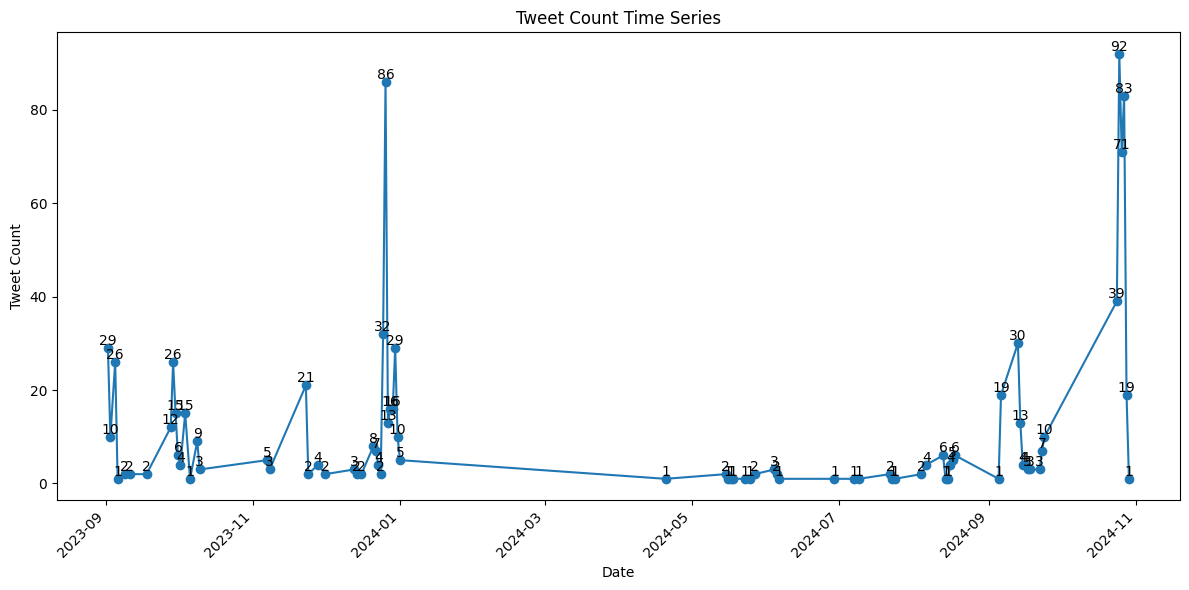

In [65]:
import matplotlib.pyplot as plt

# Group tweets by date and count the number of tweets per date
tweet_counts = combined_data_all_fix.groupby(combined_data_all_fix['created_at'].dt.date)['created_at'].count()

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(tweet_counts.index, tweet_counts.values, marker='o')  # Add markers

# Add labels to the points
for x, y in zip(tweet_counts.index, tweet_counts.values):
    plt.text(x, y, str(y), ha='center', va='bottom')  # Label with original values

plt.xlabel('Date')
plt.ylabel('Tweet Count')
plt.title('Tweet Count Time Series')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<ipython-input-68-2badabc74cc3>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tweet_counts = combined_data_all_fix.groupby(pd.Grouper(key='created_at', freq='M'))['created_at'].count()


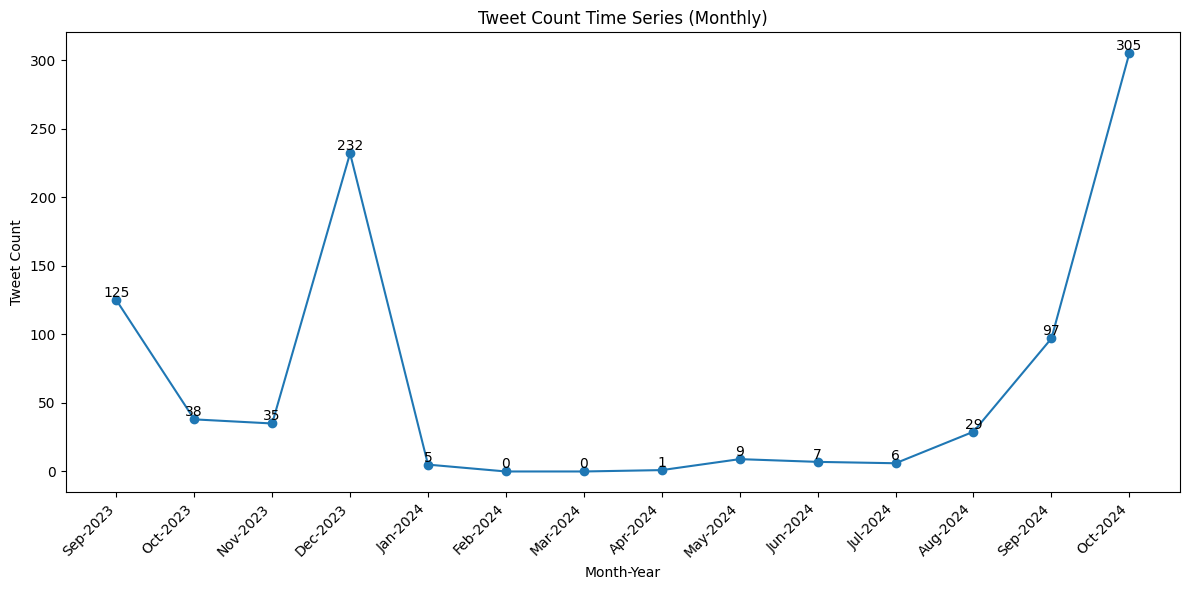

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# Group tweets by month and year and count the number of tweets
tweet_counts = combined_data_all_fix.groupby(pd.Grouper(key='created_at', freq='M'))['created_at'].count()

# Format the index to "Month-Year"
tweet_counts.index = tweet_counts.index.strftime('%b-%Y')

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(tweet_counts.index, tweet_counts.values, marker='o')

# Add labels to the points
for x, y in zip(tweet_counts.index, tweet_counts.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Month-Year')
plt.ylabel('Tweet Count')
plt.title('Tweet Count Time Series (Monthly)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<ipython-input-69-6473dde113cf>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tweet_counts = combined_data_all_fix.groupby(pd.Grouper(key='created_at', freq='M'))['created_at'].count()


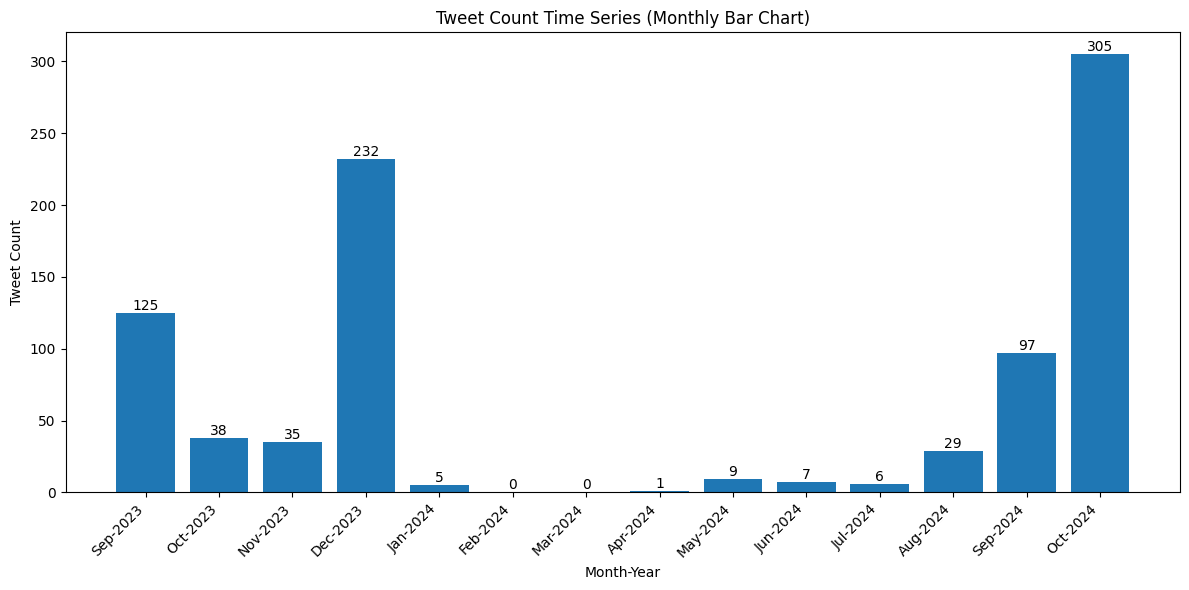

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

# Group tweets by month and year and count the number of tweets
tweet_counts = combined_data_all_fix.groupby(pd.Grouper(key='created_at', freq='M'))['created_at'].count()

# Format the index to "Month-Year"
tweet_counts.index = tweet_counts.index.strftime('%b-%Y')

# Plot the time series as a bar chart
plt.figure(figsize=(12, 6))
plt.bar(tweet_counts.index, tweet_counts.values)  # Use plt.bar for bar chart

# Add labels to the bars
for x, y in zip(tweet_counts.index, tweet_counts.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Month-Year')
plt.ylabel('Tweet Count')
plt.title('Tweet Count Time Series (Monthly Bar Chart)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [70]:
combined_data_all_fix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   conversation_id_str      120 non-null    float64            
 1   created_at               889 non-null    datetime64[ns, UTC]
 2   favorite_count           120 non-null    float64            
 3   full_text                908 non-null    object             
 4   id_str                   100 non-null    float64            
 5   image_url                11 non-null     object             
 6   in_reply_to_screen_name  32 non-null     object             
 7   lang                     120 non-null    object             
 8   location                 101 non-null    object             
 9   quote_count              120 non-null    float64            
 10  reply_count              120 non-null    float64            
 11  retweet_count            120 non

<Axes: >

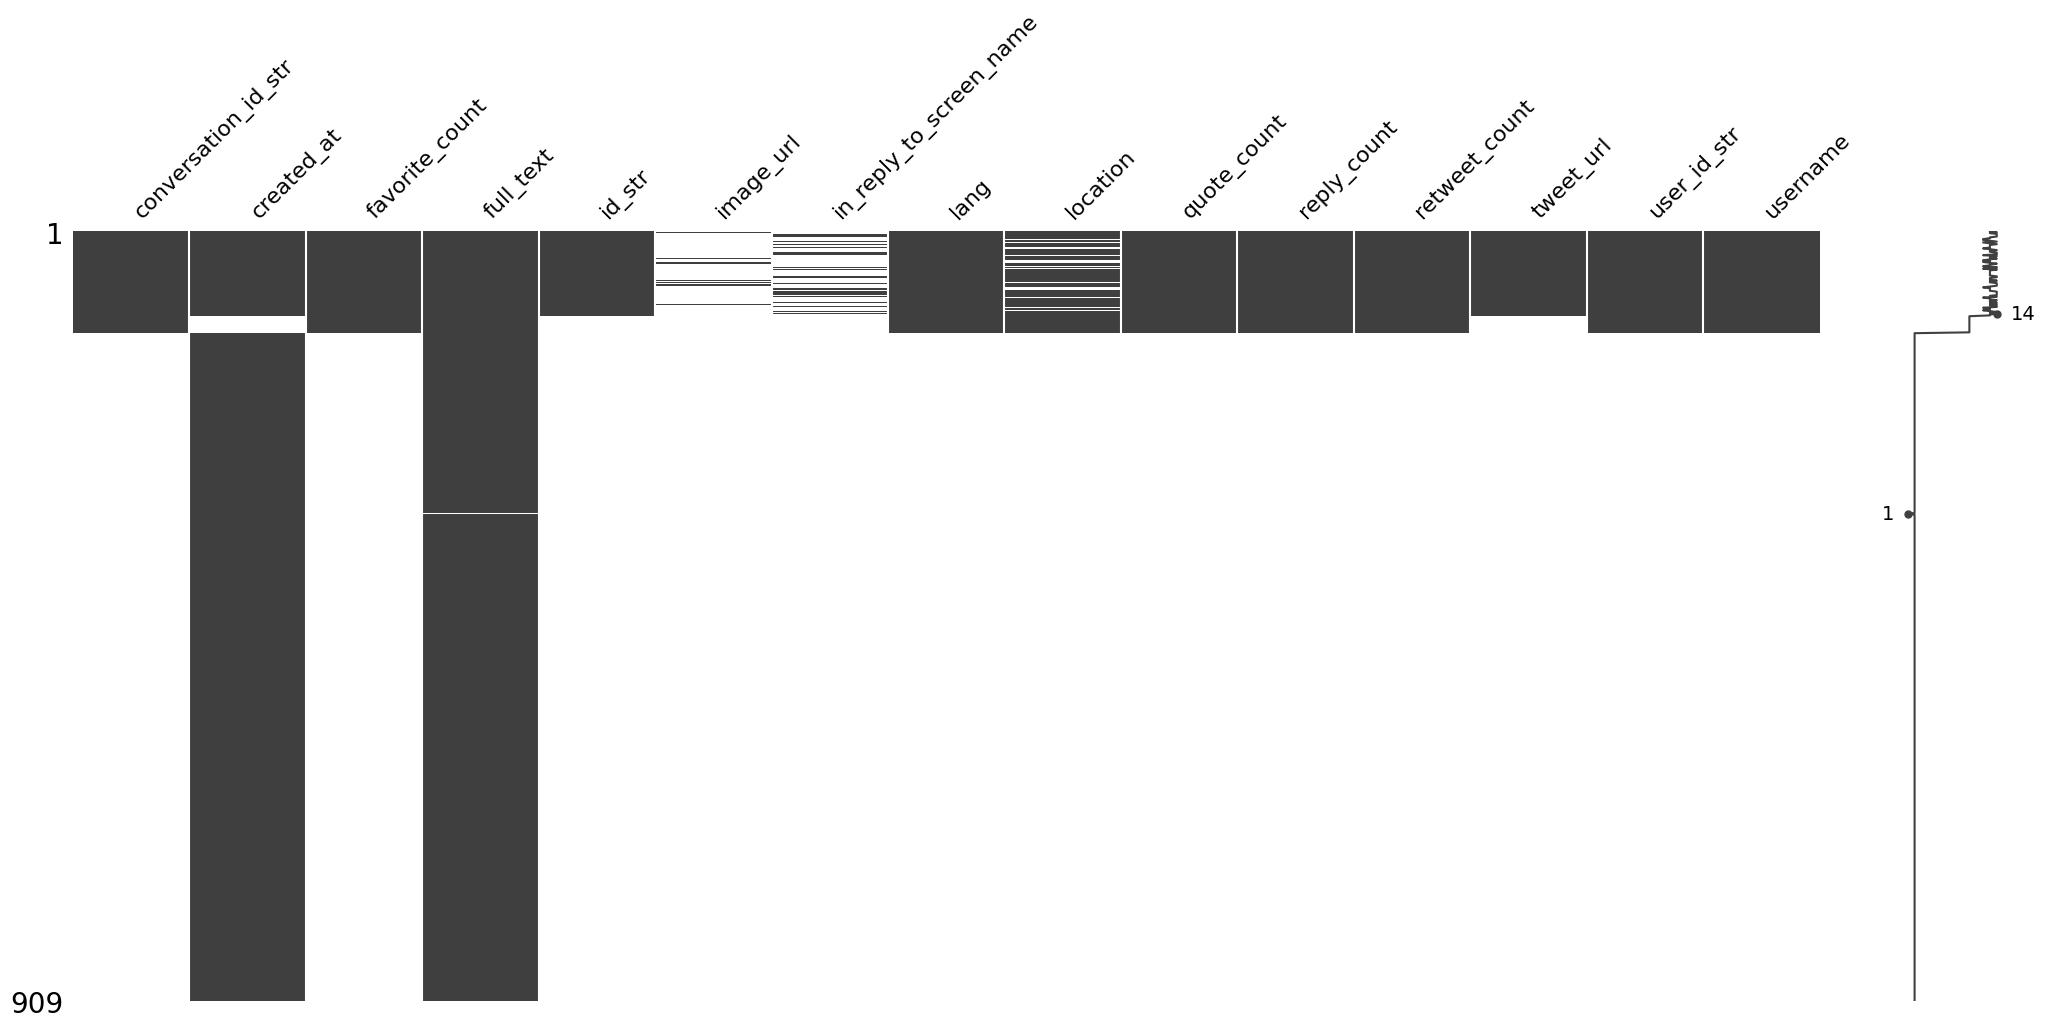

In [72]:
import missingno as mno
mno.matrix(combined_data_all_fix)

In [71]:
data_tanpa_tanggal = pd.read_csv('/content/df_cleaned_sentimen_new.csv')
data_tanpa_tanggal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      120 non-null    float64
 1   created_at               120 non-null    object 
 2   favorite_count           120 non-null    float64
 3   full_text                848 non-null    object 
 4   id_str                   100 non-null    float64
 5   image_url                11 non-null     object 
 6   in_reply_to_screen_name  32 non-null     object 
 7   lang                     120 non-null    object 
 8   location                 101 non-null    object 
 9   quote_count              120 non-null    float64
 10  reply_count              120 non-null    float64
 11  retweet_count            120 non-null    float64
 12  tweet_url                100 non-null    object 
 13  user_id_str              120 non-null    float64
 14  username                 1

In [75]:
import pandas as pd

# Convert 'created_at' to timezone unaware datetime objects
combined_data_all_fix['created_at'] = pd.to_datetime(combined_data_all_fix['created_at']).dt.tz_localize(None)

# Now you can save to Excel
combined_data_all_fix.to_excel('data_baru_add_tanggal_2.xlsx', index=False)

# Cleaning

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
import re
import nltk
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

In [ ]:
combined_data_all_fix['full_text'] = combined_data_all_fix['full_text'].astype(str)

In [ ]:
combined_data_all_fix['full_text'].head()

,full_text
0,Coba sharing pengalaman pribadi kalian berjuang untuk #KaburAjaDulu kerja ke luar negeri
1,JP SPEAKER OPPORTUNITIES 1. Japanese interpreter in automotive industries #KaburAjaDulu 6-8 M JPY/year 2. Japanese helpdesk all graduates WFO Jakarta 7 M IDR/month. Both requires N2. Send your resume to primawan@satriocs.com with the subject JP interpreter/helpdesk - https://t.co/HlzHUlcDEX
2,1-2 jam lagi aku akan share loker #KaburAjaDulu ke Jepang buat interpreter + 1 loker di Indonesia untuk fresh grad yang punya kemampuan bahasa Jepang. Mohon ditunggu~
3,Jadi temen2 yg lagi proses #KaburAjaDulu plis jangan menyerah! Ttp konsisten sm mimpi kamu jangan lupa untuk improve skill kamu jugaaaa! Aku tau jalannya pasti ga mudah tp kl km konsisten pasti akan terwujud juga! Semangaaat yaaa
4,@hrdbacot #KaburAjaDulu jalur kuliah S3 4 tahun lalu. Pas kuliah tahun terakhir akhirnya memutuskan buat lanjut kerja di sini aja dan lanjut job hunting. Sekarang sudah hampir 1 tahun kerja di sini and I m happy


#Hapus hastag

In [ ]:
# Delete isi tweets contain #KaburAjaDulu and #kaburajadulu tapi tidak di drop datanya hanya hapus tulisan tweet hashtag
combined_data_all_fix['full_text'] = combined_data_all_fix['full_text'].str.replace('#KaburAjaDulu|#kaburajadulu', '', regex=True)

In [ ]:
combined_data_all_fix['full_text'].head()

,full_text
0,Coba sharing pengalaman pribadi kalian berjuang untuk kerja ke luar negeri
1,JP SPEAKER OPPORTUNITIES 1. Japanese interpreter in automotive industries 6-8 M JPY/year 2. Japanese helpdesk all graduates WFO Jakarta 7 M IDR/month. Both requires N2. Send your resume to primawan@satriocs.com with the subject JP interpreter/helpdesk - https://t.co/HlzHUlcDEX
2,1-2 jam lagi aku akan share loker ke Jepang buat interpreter + 1 loker di Indonesia untuk fresh grad yang punya kemampuan bahasa Jepang. Mohon ditunggu~
3,Jadi temen2 yg lagi proses plis jangan menyerah! Ttp konsisten sm mimpi kamu jangan lupa untuk improve skill kamu jugaaaa! Aku tau jalannya pasti ga mudah tp kl km konsisten pasti akan terwujud juga! Semangaaat yaaa
4,@hrdbacot jalur kuliah S3 4 tahun lalu. Pas kuliah tahun terakhir akhirnya memutuskan buat lanjut kerja di sini aja dan lanjut job hunting. Sekarang sudah hampir 1 tahun kerja di sini and I m happy


## Hapus tanda Baca

In [ ]:
import re

def clean_text_column(dataframe, column_name):
    # Define regular expressions for URL, hashtag, and mention patterns
    url_pattern = r'https?://\S+|www\.\S+'
    hashtag_pattern = r'#'
    remove_account = r'@\w+\s*'
    mention_pattern = r'@'
    weird_pattern = r'&amp'
    date_pattern = r'\(\d{1,2}/\d{1,2}/\d{4}\)'

    # Remove URL links
    dataframe[column_name] = dataframe[column_name].apply(lambda x: re.sub(url_pattern, '', x))

    # Remove hashtags
    dataframe[column_name] = dataframe[column_name].apply(lambda x: re.sub(hashtag_pattern, '', x))

    # Remove account
    dataframe[column_name] = dataframe[column_name].apply(lambda x: re.sub(remove_account, '', x))

    # Remove mentions
    dataframe[column_name] = dataframe[column_name].apply(lambda x: re.sub(mention_pattern, '', x))

     # Remove weird pattern of &
    dataframe[column_name] = dataframe[column_name].apply(lambda x: re.sub(weird_pattern, 'dan', x))

    # Remove date
    dataframe[column_name] = dataframe[column_name].apply(lambda x: re.sub(date_pattern, '', x))

    # Remove characters outside of A-Z, a-z, and 0-9
    dataframe[column_name] = dataframe[column_name].apply(lambda x: re.sub(r'[^A-Za-z0-9?!@\s]', '', x))


    #dataframe[column_name] = df[column_name].apply(remove_stopwords)

    return dataframe

df_cleaned = clean_text_column(combined_data_all_fix, 'full_text')

In [ ]:
df_cleaned.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1.831921e+18,Fri Sep 06 05:04:47 +0000 2024,2999.0,Coba sharing pengalaman pribadi kalian berjuang untuk kerja ke luar negeri,1.831921e+18,NaN,NaN,in,Indonesia,427.0,157.0,697.0,https://x.com/hrdbacot/status/1831921465211650170,501800437.0,hrdbacot
1,1.832051e+18,Fri Sep 06 13:39:43 +0000 2024,262.0,JP SPEAKER OPPORTUNITIES 1 Japanese interpreter in automotive industries 68 M JPYyear 2 Japanese helpdesk all graduates WFO Jakarta 7 M IDRmonth Both requires N2 Send your resume to primawancom with the subject JP interpreterhelpdesk,1.832051e+18,https://pbs.twimg.com/media/GWy_35PXIAAPU2U.jpg,NaN,en,"Busan, Republic of Korea",15.0,8.0,119.0,https://x.com/primawansatrio/status/1832051054424502670,104823513.0,primawansatrio
2,1.832032e+18,Fri Sep 06 12:24:08 +0000 2024,69.0,12 jam lagi aku akan share loker ke Jepang buat interpreter 1 loker di Indonesia untuk fresh grad yang punya kemampuan bahasa Jepang Mohon ditunggu,1.832032e+18,NaN,NaN,in,"Busan, Republic of Korea",1.0,3.0,12.0,https://x.com/primawansatrio/status/1832032030840033597,104823513.0,primawansatrio
3,1.831979e+18,Fri Sep 06 09:28:59 +0000 2024,193.0,Jadi temen2 yg lagi proses plis jangan menyerah! Ttp konsisten sm mimpi kamu jangan lupa untuk improve skill kamu jugaaaa! Aku tau jalannya pasti ga mudah tp kl km konsisten pasti akan terwujud juga! Semangaaat yaaa,1.831988e+18,NaN,praditdita,in,神奈川県,8.0,10.0,38.0,https://x.com/praditdita/status/1831987955235463419,61713426.0,praditdita
4,1.831921e+18,Fri Sep 06 11:59:11 +0000 2024,75.0,jalur kuliah S3 4 tahun lalu Pas kuliah tahun terakhir akhirnya memutuskan buat lanjut kerja di sini aja dan lanjut job hunting Sekarang sudah hampir 1 tahun kerja di sini and I m happy,1.832026e+18,NaN,hrdbacot,in,Japan,0.0,3.0,6.0,https://x.com/petitestardust/status/1832025753976021049,223749265.0,petitestardust


In [ ]:
def clean_text(text):
    # Menghapus username
    text = re.sub(r'@\w+', '', text)

    # Menghapus tag
    text = re.sub(r'#\w+', '', text)

    # Hapus teks dalam []
    text = re.sub(r'\[\w+]', '', text)

    # Penghapusan Karakter Non-Alfanumerik
    text = re.sub(r'[^\w\s]', '', text)

    # Menghapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\b\w+(?:com|org)\b', '', text)

    # Numbers Removal: Menghapus karakter numerik
    text = re.sub(r'\d+', '', text)

    # Case Folding: Menyeragamkan teks (lower case)
    text = text.lower()

    # Menghapus whitespace (spasi ganda, tab, newline)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    #  Punctuation Removal: Menghapus tanda baca (seperti titik, koma, tanda seru, tanda tanya, dan titik koma)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tambahkan metode cleaning lainnya

    return text

In [ ]:
df_cleaned.full_text = df_cleaned.full_text.apply(clean_text)

## Hapus stopwords

In [ ]:
import nltk
import string
nltk.download('stopwords')

from nltk.corpus import stopwords
id_stopwords = stopwords.words('indonesian')

#from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary

#stop_factory = StopWordRemoverFactory().get_stop_words()
more_stopwords = [
    'yg', 'utk', 'cuman', 'deh', 'Btw', 'tapi', 'gua', 'lo', 'lu',
    'kalo', 'trs', 'jd', 'nih', 'ntar', 'nya', 'lg', 'gk', 'ecusli', 'dpt',
    'dr', 'kpn', 'kok', 'kyk', 'donk', 'yah', 'u', 'ya', 'ga', 'km', 'eh',
    'sih', 'eh', 'bang', 'br', 'kyk', 'donk', 'yah', 'u', 'ya', 'kt', 'eh',
    'mas', 'sob', 'thx', 'ato', 'jg', 'gw', 'wkwk', 'mak', 'haha', 'iy', 'k',
    'tp', 'hahaha', 'dg', 'dr', 'duh', 'ye', 'wkwkwk', 'syg', 'btw', 'gaes',
    'guys', 'moga', 'kmrn', 'nemu', 'yuk', 'wkwkw', 'kelas', 'iw', 'ew', 'lho',
    'sbnry', 'org', 'gtu', 'bwt', 'klrga', 'lbh', 'cpet', 'ku', 'wke', 'mba','mas',
    'sdh', 'kmrn', 'oi', 'spt', 'dlm', 'bs', 'krn', 'jgn', 'sapa', 'spt', 'sh', 'wakakaka',
    'sih', 'hehe', 'ih', 'dgn', 'la', 'kl', 'ttg', 'mana', 'kmna', 'kmn', 'tdk', 'tuh',
    'dah', 'kek', 'kok', 'pls', 'bbrp', 'pd', 'mah', 'kpd', 'tuh', 'kzl', 'byar', 'si', 'siii',
    'cm', 'sy', 'hahahaha', 'weh', 'dly', 'sdg', 'tuhh', 'yang', "knp", "aja", "klo", "shg",
    'untuk',
    'pada',
    'ke',
    'para',
    'namun',
    'menurut',
    'antara',
    'dia',
    'dua',
    'ia',
    'seperti',
    'jika',
    'jika',
    'sehingga',
    'kembali',
    'dan',
    'tidak',
    'ini',
    'karena',
    'kepada',
    'oleh',
    'saat',
    'harus',
    'sementara',
    'setelah',
    'belum',
    'kami',
    'sekitar',
    'bagi',
    'serta',
    'di',
    'dari',
    'telah',
    'sebagai',
    'masih',
    'hal',
    'ketika',
    'adalah',
    'itu',
    'dalam',
    'bisa',
    'bahwa',
    'atau',
    'hanya',
    'kita',
    'dengan',
    'akan',
    'juga',
    'ada',
    'mereka',
    'sudah',
    'saya',
    'terhadap',
    'secara',
    'agar',
    'lain',
    'anda',
    'begitu',
    'mengapa',
    'kenapa',
    'yaitu',
    'yakni',
    'daripada',
    'itulah',
    'lagi',
    'maka',
    'tentang',
    'demi',
    'dimana',
    'kemana',
    'pula',
    'sambil',
    'sebelum',
    'sesudah',
    'supaya',
    'guna',
    'kah',
    'pun',
    'sampai',
    'sedangkan',
    'selagi',
    'sementara',
    'tetapi',
    'apakah',
    'kecuali',
    'sebab',
    'selain',
    'seolah',
    'seraya',
    'seterusnya',
    'tanpa',
    'agak',
    'boleh',
    'dapat',
    'dsb',
    'dst',
    'dll',
    'dahulu',
    'dulunya',
    'anu',
    'demikian',
    'tapi',
    'ingin',
    'juga',
    'nggak',
    'mari',
    'nanti',
    'melainkan',
    'oh',
    'ok',
    'seharusnya',
    'sebetulnya',
    'setiap',
    'setidaknya',
    'sesuatu',
    'pasti',
    'saja',
    'toh',
    'ya',
    'walau',
    'tolong',
    'tentu',
    'amat',
    'apalagi',
    'bagaimanapun'
]

data = more_stopwords + id_stopwords

from nltk.tokenize import TweetTokenizer

def tweets_bersih(tweet):
    tokenizer = TweetTokenizer(preserve_case=False)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
      if (word not in data):
          tweets_clean.append(word)

    return tweets_clean

df_cleaned['full_text'] = df_cleaned['full_text'].apply(lambda x: tweets_bersih(x))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df_cleaned["full_text"] = df_cleaned["full_text"].apply(lambda x: ' '.join(x))

In [ ]:
# kamus 1
sl1 = {"@": "di", "abis": "habis", "ad": "ada", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}

# kamus2
sl2 = pd.read_csv("https://raw.githubusercontent.com/haryoa/indo-collex/main/dict/inforformal-formal-Indonesian-dictionary.tsv", sep="\t")
sl2.set_index("informal", drop=True, inplace=True)
sl2 = sl2.to_dict()["formal"]
sl2

# kamus 3
sl3 = pd.read_csv("https://raw.githubusercontent.com/ramaprakoso/analisis-sentimen/master/kamus/kbba.txt", sep="\t", header=None)
sl3.set_index(0, drop=True, inplace=True)
sl3 = sl3.to_dict()[1]

# Gabungkan semua kamus slang words
sl_word = {**sl1, **sl2, **sl3}

print(dict(list(sl_word.items())[1:10]))

{'abis': 'habis', 'ad': 'ada', 'adlh': 'adalah', 'afaik': 'as far as i know', 'ahaha': 'haha', 'aj': 'saja', 'ajep-ajep': 'dunia gemerlap', 'ak': 'saya', 'akika': 'aku'}


In [ ]:
# kamus 1: sastrawi
factory = StopWordRemoverFactory()
sw_id1 = factory.get_stop_words()

# kamus 2
sw_id2 = pd.read_csv("https://raw.githubusercontent.com/yasirutomo/python-sentianalysis-id/master/data/feature_list/stopwordsID.txt",header=None)
sw_id2 = list(sw_id1[0])

# kamus 3
sw_id3 = ['kalau', 'terus','banget', 'memang' 'kak']

# Tambahkan kamus lainnya
# ....

# Gabungkan
sw_id = sw_id1 + sw_id2 + sw_id3

sw_id[:20]

['yang',
 'untuk',
 'pada',
 'ke',
 'para',
 'namun',
 'menurut',
 'antara',
 'dia',
 'dua',
 'ia',
 'seperti',
 'jika',
 'jika',
 'sehingga',
 'kembali',
 'dan',
 'tidak',
 'ini',
 'karena']

In [ ]:
# Fungsi menghapus stopword
def stopwords_removal(words,stopword):
    return [word for word in words if word not in stopword]

def preprocess_text(text, slang_words = sl_word, sw = sw_id):
    # SlangWords Handling
    text = ' '.join([slang_words.get(word, word) for word in text.split()])

    # Stemming
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    text = stemmer.stem(text)

    # Stop Words Removal
    text = text.split()
    text = " ".join(stopwords_removal(text, sw))

    return text

In [ ]:
# Terapkan pada dataset
df_cleaned_pre = df_cleaned.copy()
df_cleaned.full_text = df_cleaned.full_text.apply(preprocess_text)

# Sebelum, sesudah cleaning, dan sesudah preprocessing
display(df_cleaned_pre.head(3), df_cleaned.head(3))

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1.831921e+18,Fri Sep 06 05:04:47 +0000 2024,2999.0,coba sharing pengalaman pribadi berjuang kerja negeri,1.831921e+18,NaN,NaN,in,Indonesia,427.0,157.0,697.0,https://x.com/hrdbacot/status/1831921465211650170,501800437.0,hrdbacot
1,1.832051e+18,Fri Sep 06 13:39:43 +0000 2024,262.0,jp speaker opportunities japanese interpreter in automotive industries m jpyyear japanese helpdesk all graduates wfo jakarta m idrmonth both requires n send your resume to with the subject jp interpreterhelpdesk,1.832051e+18,https://pbs.twimg.com/media/GWy_35PXIAAPU2U.jpg,NaN,en,"Busan, Republic of Korea",15.0,8.0,119.0,https://x.com/primawansatrio/status/1832051054424502670,104823513.0,primawansatrio
2,1.832032e+18,Fri Sep 06 12:24:08 +0000 2024,69.0,jam share loker jepang interpreter loker indonesia fresh grad kemampuan bahasa jepang mohon ditunggu,1.832032e+18,NaN,NaN,in,"Busan, Republic of Korea",1.0,3.0,12.0,https://x.com/primawansatrio/status/1832032030840033597,104823513.0,primawansatrio


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1.831921e+18,Fri Sep 06 05:04:47 +0000 2024,2999.0,coba alam pribadi juang kerja negeri,1.831921e+18,NaN,NaN,in,Indonesia,427.0,157.0,697.0,https://x.com/hrdbacot/status/1831921465211650170,501800437.0,hrdbacot
1,1.832051e+18,Fri Sep 06 13:39:43 +0000 2024,262.0,jp speaker opportunities japanese interpreter automotive industries m jpyyear japanese helpdesk all graduates wfo jakarta m idrmonth both requires send your resume to with the subject jp interpreterhelpdesk,1.832051e+18,https://pbs.twimg.com/media/GWy_35PXIAAPU2U.jpg,NaN,en,"Busan, Republic of Korea",15.0,8.0,119.0,https://x.com/primawansatrio/status/1832051054424502670,104823513.0,primawansatrio
2,1.832032e+18,Fri Sep 06 12:24:08 +0000 2024,69.0,jam share loker jepang interpreter loker indonesia fresh grad mampu bahasa jepang mohon tunggu,1.832032e+18,NaN,NaN,in,"Busan, Republic of Korea",1.0,3.0,12.0,https://x.com/primawansatrio/status/1832032030840033597,104823513.0,primawansatrio


In [ ]:
# Sebelum, sesudah cleaning, dan sesudah preprocessing
display(df_cleaned_pre.head(3), df_cleaned.head(3))

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1.831921e+18,2024-09-06 05:04:47+00:00,2999.0,coba sharing pengalaman pribadi berjuang kaburajadulu kerja negeri,1.831921e+18,NaN,NaN,in,Indonesia,427.0,157.0,697.0,https://x.com/hrdbacot/status/1831921465211650170,501800437.0,hrdbacot
1,1.832051e+18,2024-09-06 13:39:43+00:00,262.0,jp speaker opportunities japanese interpreter in automotive industries kaburajadulu m jpyyear japanese helpdesk all graduates wfo jakarta m idrmonth both requires n send your resume to with the subject jp interpreterhelpdesk,1.832051e+18,https://pbs.twimg.com/media/GWy_35PXIAAPU2U.jpg,NaN,en,"Busan, Republic of Korea",15.0,8.0,119.0,https://x.com/primawansatrio/status/1832051054424502670,104823513.0,primawansatrio
2,1.832032e+18,2024-09-06 12:24:08+00:00,69.0,jam share loker kaburajadulu jepang interpreter loker indonesia fresh grad kemampuan bahasa jepang mohon ditunggu,1.832032e+18,NaN,NaN,in,"Busan, Republic of Korea",1.0,3.0,12.0,https://x.com/primawansatrio/status/1832032030840033597,104823513.0,primawansatrio


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1.831921e+18,2024-09-06 05:04:47+00:00,2999.0,coba alam pribadi juang kaburajadulu kerja negeri,1.831921e+18,NaN,NaN,in,Indonesia,427.0,157.0,697.0,https://x.com/hrdbacot/status/1831921465211650170,501800437.0,hrdbacot
1,1.832051e+18,2024-09-06 13:39:43+00:00,262.0,jp speaker opportunities japanese interpreter automotive industries kaburajadulu m jpyyear japanese helpdesk all graduates wfo jakarta m idrmonth both requires send your resume to with the subject jp interpreterhelpdesk,1.832051e+18,https://pbs.twimg.com/media/GWy_35PXIAAPU2U.jpg,NaN,en,"Busan, Republic of Korea",15.0,8.0,119.0,https://x.com/primawansatrio/status/1832051054424502670,104823513.0,primawansatrio
2,1.832032e+18,2024-09-06 12:24:08+00:00,69.0,jam share loker kaburajadulu jepang interpreter loker indonesia fresh grad mampu bahasa jepang mohon tunggu,1.832032e+18,NaN,NaN,in,"Busan, Republic of Korea",1.0,3.0,12.0,https://x.com/primawansatrio/status/1832032030840033597,104823513.0,primawansatrio


In [ ]:
df_cleaned.to_csv('df_cleaned_new.csv', index=False)

# Trend Line

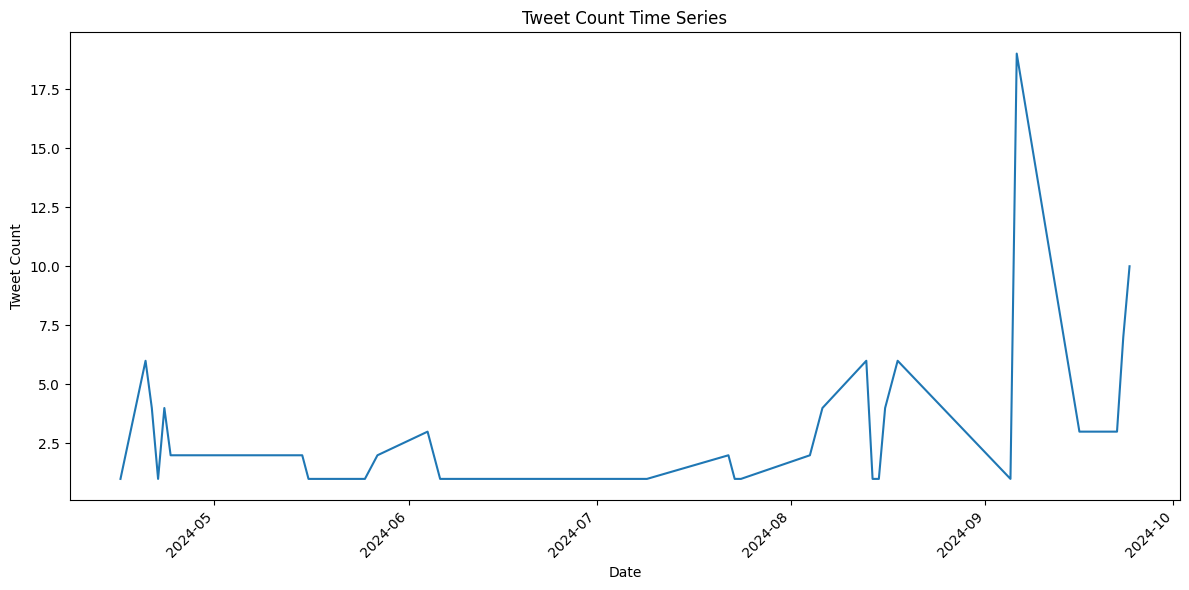

In [ ]:
import matplotlib.pyplot as plt

# ... (Your previous code to prepare combined_data_all_fix) ...

# Group tweets by date and count the number of tweets per date
tweet_counts = df_cleaned.groupby(df_cleaned['created_at'].dt.date)['created_at'].count()

# Plot the time series
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
plt.plot(tweet_counts.index, tweet_counts.values)
plt.xlabel('Date')
plt.ylabel('Tweet Count')
plt.title('Tweet Count Time Series')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# Sentimen

In [ ]:
# Sentimen Analysis

!pip install transformers

from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification

pretrained= "mdhugol/indonesia-bert-sentiment-classification"

model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

label_index = {'LABEL_0': 'positive', 'LABEL_1': 'neutral', 'LABEL_2': 'negative'}

config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
df_cleaned

In [ ]:
from tqdm import tqdm
tqdm.pandas(desc='My bar!')

df_cleaned['sentiment_label'] = df_cleaned['full_text'].progress_apply(lambda x: label_index[sentiment_analysis(str(x))[0]['label']])

My bar!: 100%|██████████| 909/909 [02:22<00:00,  6.40it/s]


In [ ]:
df_cleaned.to_csv('df_cleaned_sentimen_new.csv',index=False)

In [ ]:
# sebelum hapus jangan dirun
df_cleaned['sentiment_label'].value_counts()

,count
sentiment_label,
negative,278
neutral,197
positive,155


In [ ]:
df_cleaned['sentiment_label'].value_counts()

,count
sentiment_label,
negative,398
neutral,273
positive,238


In [ ]:
# setelah dihapus
df_cleaned['sentiment_label'].value_counts()

,count
sentiment_label,
positive,307
negative,304
neutral,298


In [ ]:
# show head for df_cleaned['sentiment_label'] each label
df_cleaned[df_cleaned['sentiment_label'] == 'negative'].head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,sentiment_label
5,1.831921e+18,Fri Sep 06 13:58:56 +0000 2024,97.0,teman teman doa cepat kuliah kerja negeri cepat allah gerah sangat indonesia pejabrut perintah kotor semua,1.832056e+18,NaN,hrdbacot,in,mozarela,3.0,3.0,15.0,https://x.com/mmoozzaarreella/status/1832055890150936760,1.106422e+18,mmoozzaarreella,negative
6,1.831989e+18,Fri Sep 06 09:36:20 +0000 2024,48.0,senior high demand uang title terminal promosi mati aman visa gampang gaji cari supplynya dikit mudah saran,1.831990e+18,NaN,lwastuargo,in,🟩🟩🟩🟨⬜⬜⬜⬜⬜⬜ 1000 students,0.0,0.0,4.0,https://x.com/lwastuargo/status/1831989804768403678,2.729634e+08,lwastuargo,negative
7,1.831713e+18,Thu Sep 05 15:17:31 +0000 2024,2.0,pikir pusing indonesia indomaret lelah lihat ngang ngeng ngong perintah,1.831713e+18,NaN,NaN,in,Want to know more? →,0.0,0.0,2.0,https://x.com/akunbeben/status/1831713276591534122,1.002940e+18,akunbeben,negative
8,1.831999e+18,Fri Sep 06 10:12:56 +0000 2024,0.0,kaburajadulu,1.831999e+18,NaN,NaN,qht,Indonesia,0.0,0.0,0.0,https://x.com/n1ketas/status/1831999015011168348,7.493513e+17,n1ketas,negative
10,1.832068e+18,Fri Sep 06 14:45:46 +0000 2024,0.0,nonskilled workers alam sekretaris urus surat huhu upgrade bingung mana,1.832068e+18,NaN,NaN,in,NaN,0.0,0.0,0.0,https://x.com/idkmeither2/status/1832067675029217663,1.498274e+18,idkmeither2,negative


In [ ]:
df_cleaned[df_cleaned['sentiment_label'] == 'negative'].head(10)

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,sentiment_label
0,1.831921e+18,2024-09-06 05:04:47+00:00,2999.0,coba alam pribadi juang kaburajadulu kerja negeri,1.831921e+18,NaN,NaN,in,Indonesia,427.0,157.0,697.0,https://x.com/hrdbacot/status/1831921465211650170,5.018004e+08,hrdbacot,negative
5,1.831921e+18,2024-09-06 13:58:56+00:00,97.0,teman teman doa cepat kaburajadulu kuliah kerja negeri cepat allah gerah sangat indonesia pejabrut perintah kotor semua,1.832056e+18,NaN,hrdbacot,in,mozarela,3.0,3.0,15.0,https://x.com/mmoozzaarreella/status/1832055890150936760,1.106422e+18,mmoozzaarreella,negative
6,1.831989e+18,2024-09-06 09:36:20+00:00,48.0,senior high demand uang title terminal promosi mati aman visa gampang gaji cari supplynya dikit mudah kaburajadulu saran,1.831990e+18,NaN,lwastuargo,in,🟩🟩🟩🟨⬜⬜⬜⬜⬜⬜ 1000 students,0.0,0.0,4.0,https://x.com/lwastuargo/status/1831989804768403678,2.729634e+08,lwastuargo,negative
7,1.831713e+18,2024-09-05 15:17:31+00:00,2.0,pikir kaburajadulu pusing indonesia indomaret lelah lihat ngang ngeng ngong perintah,1.831713e+18,NaN,NaN,in,Want to know more? →,0.0,0.0,2.0,https://x.com/akunbeben/status/1831713276591534122,1.002940e+18,akunbeben,negative
8,1.831999e+18,2024-09-06 10:12:56+00:00,0.0,kaburajadulu,1.831999e+18,NaN,NaN,qht,Indonesia,0.0,0.0,0.0,https://x.com/n1ketas/status/1831999015011168348,7.493513e+17,n1ketas,negative
9,1.832114e+18,2024-09-06 17:49:35+00:00,0.0,usaha kaburajadulu,1.832114e+18,NaN,NaN,in,NaN,0.0,0.0,0.0,https://x.com/moiraeirene/status/1832113932984840623,1.052449e+18,moiraeirene,negative
10,1.832068e+18,2024-09-06 14:45:46+00:00,0.0,kaburajadulu nonskilled workers alam sekretaris urus surat huhu upgrade bingung mana,1.832068e+18,NaN,NaN,in,NaN,0.0,0.0,0.0,https://x.com/idkmeither2/status/1832067675029217663,1.498274e+18,idkmeither2,negative
11,1.831956e+18,2024-09-06 07:21:37+00:00,2702.0,andai gaji gurudosen teliti nakes begini besar indonesia kaya singapore gera kaburajadulu indonesia brain drain,1.831956e+18,NaN,NaN,in,Indonesia,46.0,87.0,1245.0,https://x.com/hrdbacot/status/1831955900090962361,5.018004e+08,hrdbacot,negative
13,1.832127e+18,2024-09-06 18:39:39+00:00,1.0,kaburajadulu minggat indonesia alas utama sudi bayar pajak perintah aku equality lgbt jmn lgbt issue selalu goreng otak pakai kuliah teknik kerja th ngejongkrok sini pindah kota,1.832127e+18,NaN,NaN,in,NaN,0.0,0.0,0.0,https://x.com/boluubi/status/1832126535106752716,9.868948e+17,boluubi,negative
14,1.832085e+18,2024-09-06 15:54:03+00:00,0.0,negara malu rakyat bikin hashtag kaburajadulu isi rakyat opportunity negara malu demand this country has gagal,1.832085e+18,NaN,NaN,in,MDNI.,0.0,0.0,1.0,https://x.com/aioride/status/1832084859961163779,1.220959e+18,aioride,negative


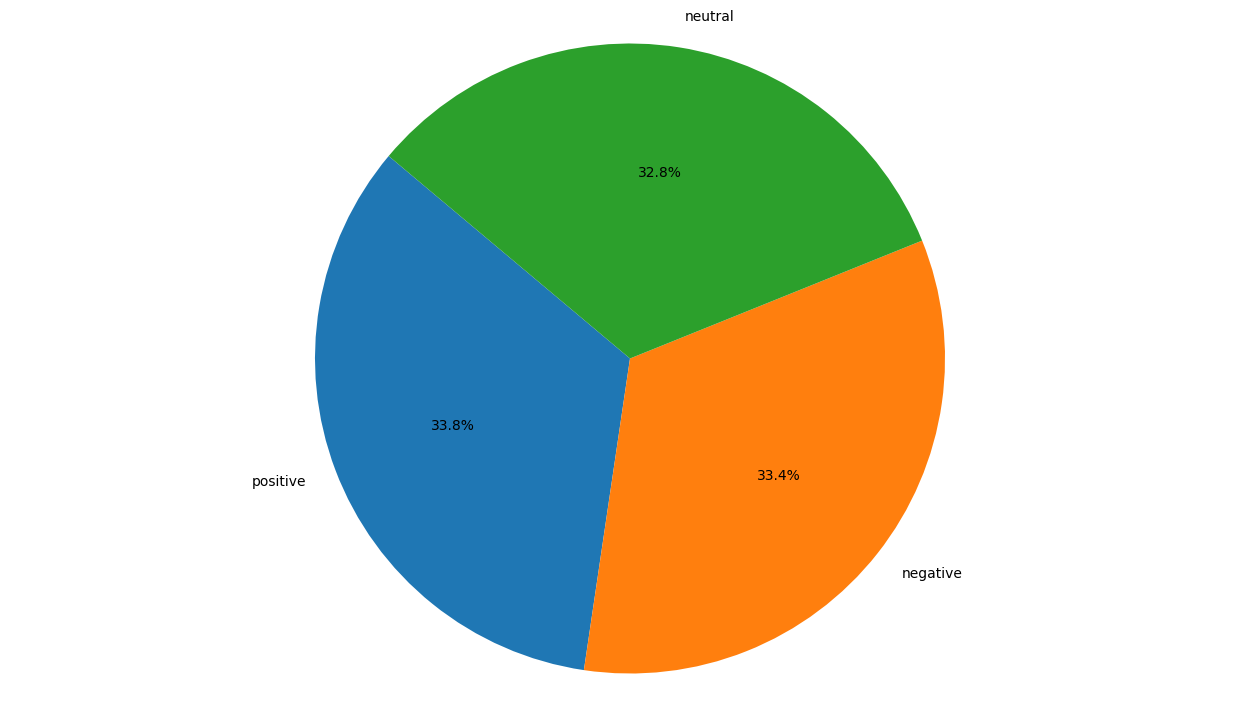

In [ ]:
import matplotlib.pyplot as plt

# Count the occurrences of each category
category_counts = df_cleaned['sentiment_label'].value_counts()
# Plot the pie chart
plt.figure(figsize=(16, 9))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
#plt.title(f'Pie Chart of {category_column_name}')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the pie chart
#plt.savefig('pie_chart_sentiment_analysis_uktpinjol.png')
#plt.savefig('barchart - sentiment.png')
plt.show()

# WordCloud

Text(0.5, 1.0, 'Word Cloud')

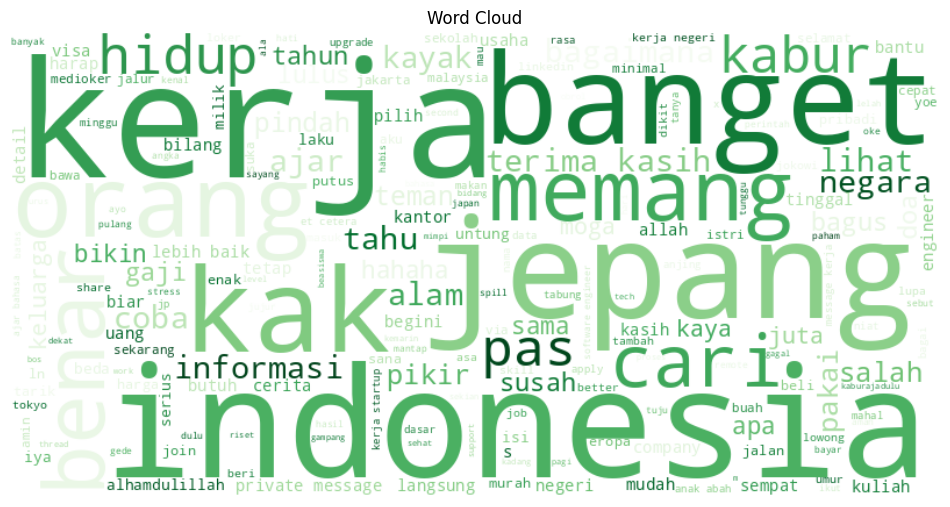

In [ ]:
#!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(df_cleaned['full_text'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(all_text)

# Display the generated image:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud')

In [ ]:
# in all text delete word 'kalau','terus','banget','memang','kak'
all_text_new = ' '.join(df_cleaned['full_text'].astype(str))
all_text_new = all_text_new.replace('kalau', '')
all_text_new = all_text_new.replace('terus', '')
all_text_new = all_text_new.replace('kak', '')
all_text_new = all_text_new.replace('banget', '')
all_text_new = all_text_new.replace('memang', '')
all_text_new

'coba alam pribadi juang kerja negeri jp speaker opportunities japanese interpreter automotive industries m jpyyear japanese helpdesk all graduates wfo jakarta m idrmonth both requires send your resume to with the subject jp interpreterhelpdesk jam share loker jepang interpreter loker indonesia fresh grad mampu bahasa jepang mohon tunggu teman proses please serah tetap konsisten sama mimpi lupa improve skill jugaaaa tahu jalan mudah konsisten wujud semangaaat jalur kuliah s pas kuliah putus kerja job hunting kerja and i m bahagia teman teman doa cepat kuliah kerja negeri cepat allah gerah sangat indonesia pejabrut perintah kotor semua senior high demand uang title terminal promosi mati aman visa gampang gaji cari supplynya dikit mudah saran pikir pusing indonesia indomaret lelah lihat ngang ngeng ngong perintah kaburajadulu usaha nonskilled workers alam sekretaris urus surat huhu upgrade bingung mana andai gaji gurudosen teliti nakes begini besar indonesia kaya singapore gera indonesia

Text(0.5, 1.0, 'Word Cloud')

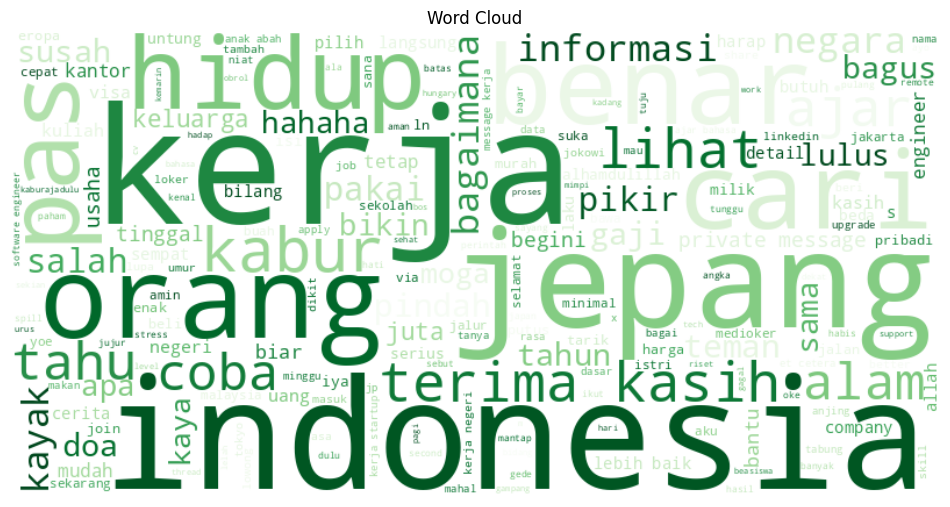

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(all_text_new)

# Display the generated image:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud')

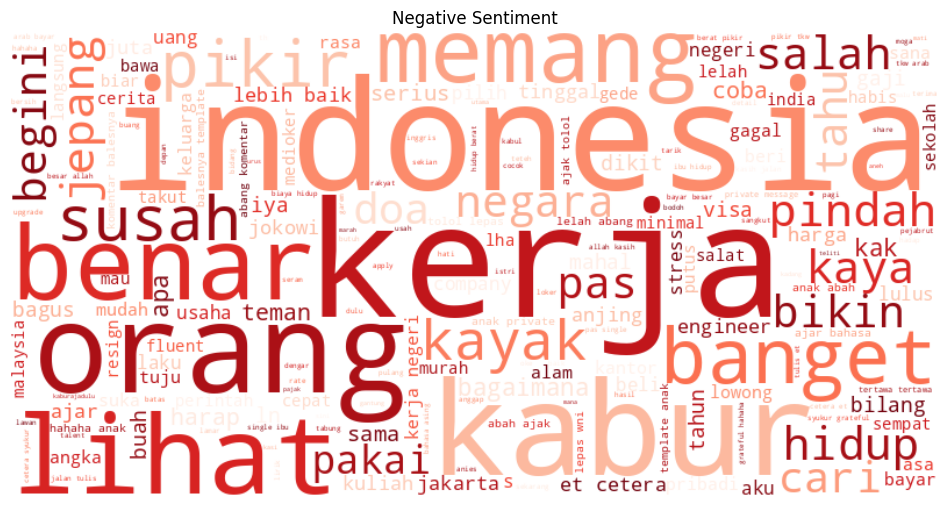

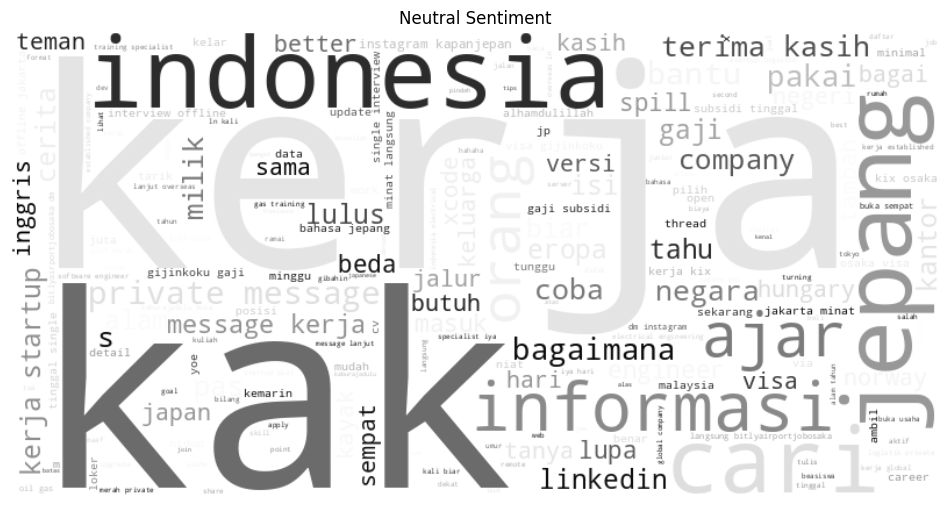

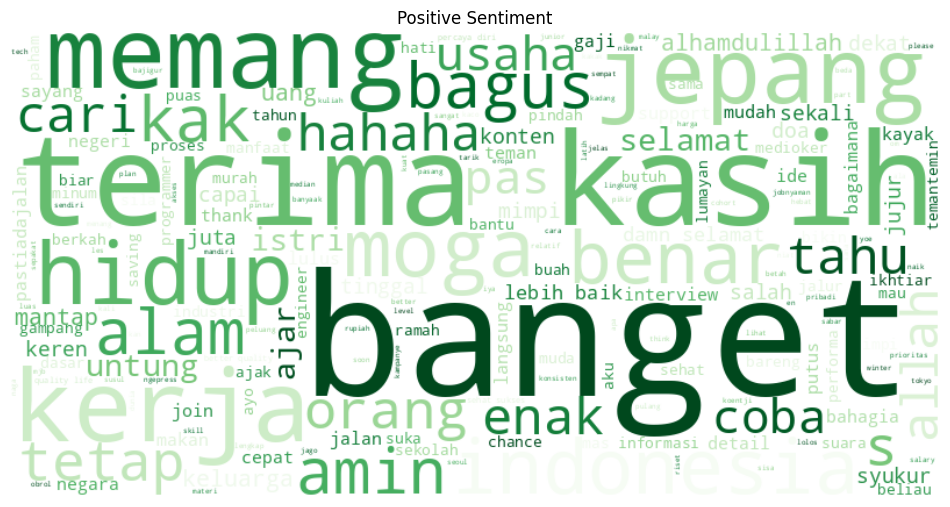

In [ ]:
#!pip install wordcloud


# Group data by sentiment
negative_tweets = df_cleaned[df_cleaned['sentiment_label'] == 'negative']['full_text'].str.cat(sep=' ')
neutral_tweets = df_cleaned[df_cleaned['sentiment_label'] == 'neutral']['full_text'].str.cat(sep=' ')
positive_tweets = df_cleaned[df_cleaned['sentiment_label'] == 'positive']['full_text'].str.cat(sep=' ')

# Create word clouds for each sentiment
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_tweets)
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white', colormap='Greys').generate(neutral_tweets)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_tweets)

# Display the generated image:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.title('Negative Sentiment')
#plt.savefig('wordcloud_negative.png')
plt.show()

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.axis("off")
plt.title('Neutral Sentiment')
#plt.savefig('wordcloud_neutral.png')
plt.show()

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.title('Positive Sentiment')
#plt.savefig('wordcloud_positive.png')
plt.show()

# banget memang kak

In [ ]:
# in all tweets delete word 'kalau','terus','banget','memang','kak'
negative_tweets = negative_tweets.replace('kalau', '')
negative_tweets = negative_tweets.replace('terus', '')
negative_tweets = negative_tweets.replace('kak', '')
negative_tweets = negative_tweets.replace('banget', '')
negative_tweets = negative_tweets.replace('memang', '')
neutral_tweets = neutral_tweets.replace('kalau', '')
neutral_tweets = neutral_tweets.replace('terus', '')
neutral_tweets = neutral_tweets.replace('kak', '')
neutral_tweets = neutral_tweets.replace('banget', '')
neutral_tweets = neutral_tweets.replace('memang', '')
positive_tweets = positive_tweets.replace('kalau', '')
positive_tweets = positive_tweets.replace('terus', '')
positive_tweets = positive_tweets.replace('kak', '')
positive_tweets = positive_tweets.replace('banget', '')
positive_tweets = positive_tweets.replace('memang', '')

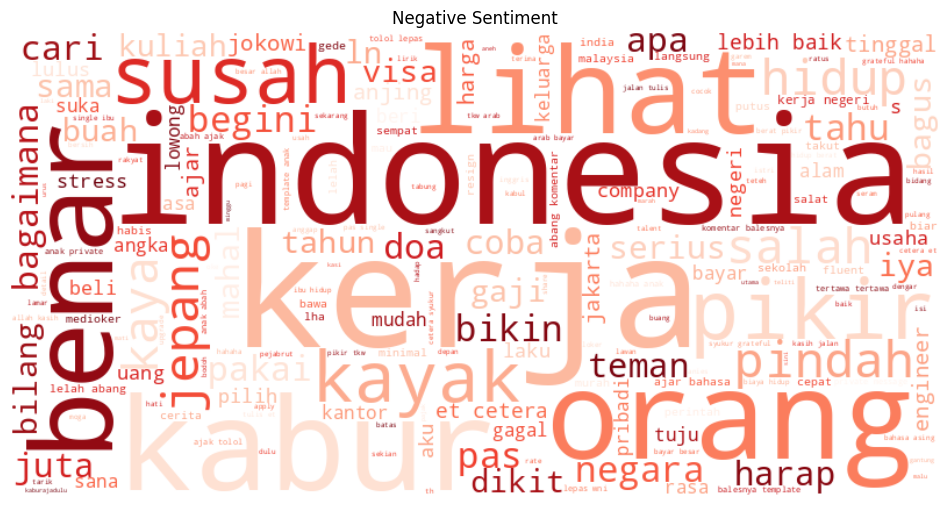

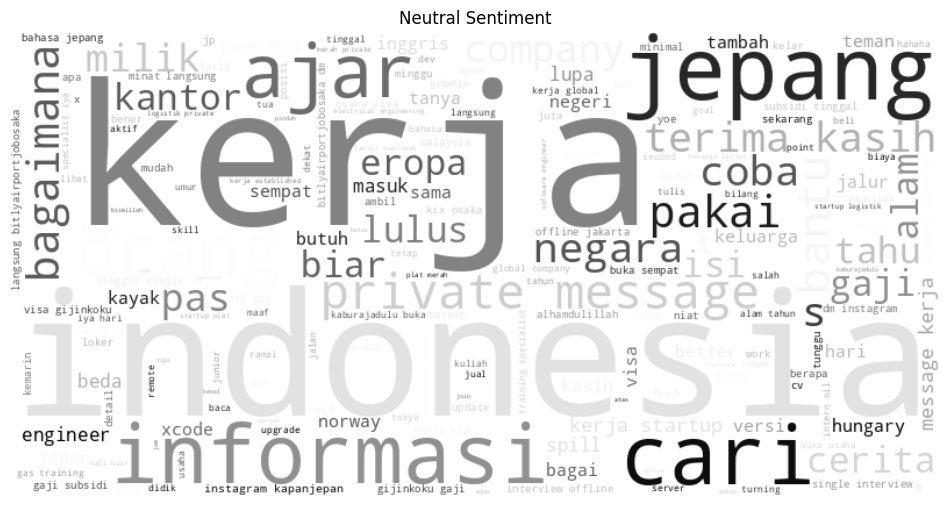

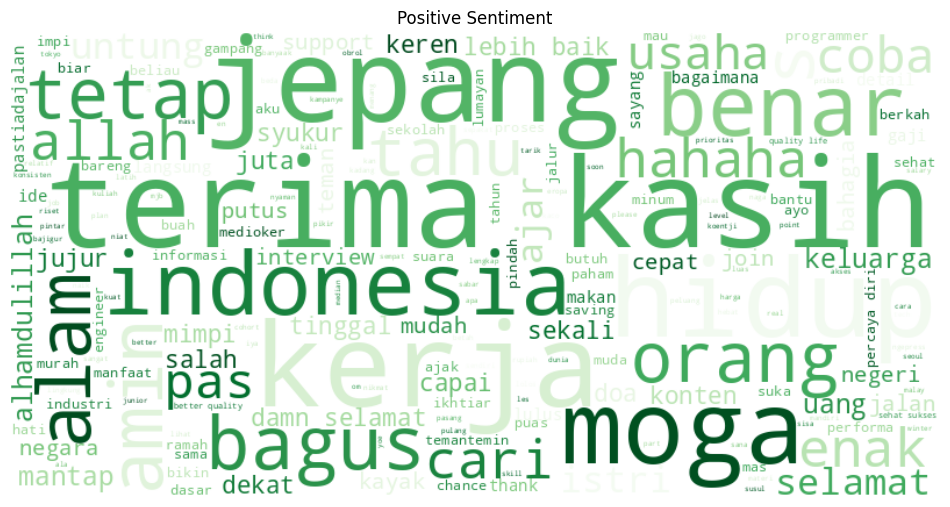

In [ ]:
# Create word clouds for each sentiment
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_tweets)
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white', colormap='Greys').generate(neutral_tweets)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_tweets)

# Display the generated image:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.title('Negative Sentiment')
#plt.savefig('wordcloud_negative.png')
plt.show()

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.axis("off")
plt.title('Neutral Sentiment')
#plt.savefig('wordcloud_neutral.png')
plt.show()

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.title('Positive Sentiment')
#plt.savefig('wordcloud_positive.png')
plt.show()

# Topic Modelling

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.5 MB/s eta 0:00:00


In [ ]:
full_text = df_cleaned['full_text']
full_text = full_text.astype(str)

In [ ]:
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired

representation_model = KeyBERTInspired()
topic_model = BERTopic(language="multilingual", representation_model=representation_model)
topics, probs = topic_model.fit_transform(full_text)

In [ ]:
#lawas
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,184,-1_intern_oil_training_engineering,"[intern, oil, training, engineering, kerja, company, industri, overseas, gas, electrical]","[intern oil gas training specialist iya hari kerja global company indonesia electrical engineering kerja startup logistik private message kerja startup plat merah private message kerja established company private message lanjut overseas ln kali biar kaburajadulu, intern oil gas training specialist iya hari kerja global company indonesia electrical engineering kerja startup logistik private message kerja startup plat merah private message kerja established company private message lanjut overseas ln kali biar kaburajadulu, intern oil gas training specialist iya hari kerja global company indonesia electrical engineering kerja startup logistik private message kerja startup plat merah private message kerja established company private message lanjut overseas ln kali biar kaburajadulu]"
1,0,179,0_keren_pantas_suka_lumayan,"[keren, pantas, suka, lumayan, banyaak, alhamdulillah, sempat, selamat, banget, jejak]","[berapa krg tahu keluar beda tahu coba kalkulasi pakai poin breakdown twit angka berapa cocok utkmu tabung kasih orang tua, mjb kak materiny lengkap dasar banget, ayo coba jam kerja fleksibel nyaa lumayan banget lhoo start jtminggu ktp aman banget pokoknyaaa bowlehh lumayan banget kan]"
2,1,74,1_kaburajadulu_liburanajadulu_pergiajadulu_mimpiajadulu,"[kaburajadulu, liburanajadulu, pergiajadulu, mimpiajadulu, benua, ikhtiar, yurop, versi, milik, lintas]","[kaburajadulu, kaburajadulu, kaburajadulu]"
3,2,63,2_jepang_jepangnya_japanese_japan,"[jepang, jepangnya, japanese, japan, tokyo, yokohama, kaijisan, nihongo, sukoshi, moga]","[tutup kasih simpul reply kaijisan founder kapanjepan terima kasih kaijisan beri added poin attached share sudut pandang keluarga banyak teman single reply bilang tabung bilang ngepas tulis umr tokyo gada bilang underpaid rate begini rate normal japanese engineer tmntmn outlier share rate rate normal bidang engineer lupa share intangible benefit taraf hidup baik udara bersih air bersih transportasi publik bagus banyak twit faktor keluarga sandwich gen tahu sekarang tahu standardnya segimana tangible intangible benefitnya tugas selaras kondisi beda hitung rinci salah standardnya alhamdulillah coba usah bilang aneh tahu hidup social media moga mimpi tinggal jepang wujud jalan baik amin, kaburajadulu jepang, kaburajadulu jepang]"
4,3,57,3_indonesia_jakarta_thai_malaysia,"[indonesia, jakarta, thai, malaysia, yawis, jepang, manfaatin, singapura, kaburajadulu, kabur]","[mudah indonesia pindah company indonesia teman jepang back for bagus indonesia kantor gantung company mudah, angka cocok turut lowong level angka yawis upgrade dulu alam indonesia leluasa cari lowong cocok yoe again kaburajadulu larang, angka cocok turut lowong level angka yawis upgrade dulu alam indonesia leluasa cari lowong cocok yoe again kaburajadulu larang]"
5,4,54,4_allah_itadaki_percaya_ngamalin,"[allah, itadaki, percaya, ngamalin, masyaallah, tuhanwalau, skripsinyaa, lulus, hati, gibahin]","[aman untung sadar part tampolan allah syukur memang tenang hati kueenceng prinsip goyang liat enak bablas lebih baik pas bablas hati gelisah enjoy gelisah susah iman setip rempeyek begini memang tantang istiqomah yoyo better drpada loss sekali, doa batin kak salat fardhu fixed baca ditambahin batalin salat salat sunnah batin sujud jujur jarang ngamalin doa khusus doa kaya curah hati povnya batin, doa boleeeh gengsi kak hahaha jatohnya sombong doa hadist nyebutin garem doa habis doa diem harap tiba garem muncul cumaa dosa better doa bareng istigfar tahu hina dina begini macam ampun tadi mentang rasa dosa malu tetap insya allah kabul entah sesuai kasi best case doa kabul dunia kabul akhirat]"
6,5,50,5_ijazah_career_graduate_job,"[ijazah, career, graduate, job, bos, lulus, kuliah, kerja, sekolah, probation]","[langsung job searching modeon kelar probation kantor rasa 

In [ ]:
topic_model.get_topic(5)

[('ijazah', 0.54120564),
 ('career', 0.53066975),
 ('graduate', 0.49479926),
 ('job', 0.49227577),
 ('bos', 0.47495472),
 ('lulus', 0.4473562),
 ('kuliah', 0.43356827),
 ('kerja', 0.42551023),
 ('sekolah', 0.3997712),
 ('probation', 0.3957161)]

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,290,-1_message_intern_private_kak,"[message, intern, private, kak, seram, ajar, et, bikin, informasi, teman]","[intern oil gas training specialist iya hari kerja global company indonesia electrical engineering kerja startup logistik private message kerja startup plat merah private message kerja established company private message lanjut overseas ln kali biar, intern oil gas training specialist iya hari kerja global company indonesia electrical engineering kerja startup logistik private message kerja startup plat merah private message kerja established company private message lanjut overseas ln kali biar, intern oil gas training specialist iya hari kerja global company indonesia electrical engineering kerja startup logistik private message kerja startup plat merah private message kerja established company private message lanjut overseas ln kali biar]"
1,0,112,0_engineer_career_bos_recruiting,"[engineer, career, bos, recruiting, job, kerja, engineering, tech, kantor, ijazah]","[maaf kak memang benar tahu kayak orang kerja negeri lpk orang didik kayak s kerja usaha ln kantor lpk lulus sama s, about overpopulated software engineer benar banget cari benar bagus memang susah susah bikin workshop femes kaya sama profunder kaya kabur ck lebih baik medioker kabur, about overpopulated software engineer benar banget cari benar bagus memang susah susah bikin workshop femes kaya sama profunder kaya kabur ck lebih baik medioker kabur]"
2,1,70,1_kanada_related_noted_,"[kanada, related, noted, , , , , , , ]","[cant related, kanada, kanada]"
3,2,64,2_jepang_japan_japanese_jepangnya,"[jepang, japan, japanese, jepangnya, tokyo, yokohama, korea, kaijisan, foreigner, seoul]","[tutup kasih simpul reply kaijisan founder kapanjepan terima kasih kaijisan beri added poin attached share sudut pandang keluarga banyak teman single reply bilang tabung bilang ngepas tulis umr tokyo gada bilang underpaid rate begini rate normal japanese engineer tmntmn outlier share rate rate normal bidang engineer lupa share intangible benefit taraf hidup baik udara bersih air bersih transportasi publik bagus banyak twit faktor keluarga sandwich gen tahu sekarang tahu standardnya segimana tangible intangible benefitnya tugas selaras kondisi beda hitung rinci salah standardnya alhamdulillah coba usah bilang aneh tahu hidup social media moga mimpi tinggal jepang wujud jalan baik amin, jepang, jepang]"
4,3,62,3_indonesia_jakarta_thai_malaysia,"[indonesia, jakarta, thai, malaysia, gaji, kerja, singapura, kriteria, manfaat, manfaatin]","[point out gaji jutasetahun posisiposisi sesuai pasar benerab kayak cari kerja murah manfaatin animo orang indonesia beda cerita gaji posisi pabrikperkebunan, angka cocok turut lowong level angka yawis upgrade dulu alam indonesia leluasa cari lowong cocok yoe again larang, angka cocok turut lowong level angka yawis upgrade dulu alam indonesia leluasa cari lowong cocok yoe again larang]"
5,4,36,4_pastiadajalan_harap_terusin_sempat,"[pastiadajalan, harap, terusin, sempat, jangka, ikut, putus, sebentar, rencana, pantas]","[lha usir apa sangkut, ngerusak occassionallynya rencana bulan minggu bayang beli tiket staycation weekend lembur, lha usir apa sangkut]"
6,5,35,5_gaung_simak_prkemudian_panjat,"[gaung, simak, prkemudian, panjat, pinang, koreksi, gegabah, nokkg, selat, rasuk]","[spe lomba anak aktif spe ui, pas periode oke periode kaya rasuk syaiton, anies saged ndandakne sego nik coffebit tanglet jeneng]"
7,6,30,6_uang_ongkos_stipendiumhungaricumhu_mahal,"[uang, ongkos, stipendiumhungaricumhu, mahal, income, biaya, rentenir, juta, bayar, harga]","[cerita putus ambil hungary banyak informasi trkait negara nekat tarik jalur ajar stipendiumhungaricumhu, lulus wisuda tahu orang tua hutang ratus juta juta rentenir bulan tambah beraniin pinjm bank jamin nerusin usaha ternak lele tembus juta juta bayar rentenir juta ekspansi juta danadarurat, cerita putus ambil hungary banyak informasi trkait nega

In [ ]:
topic_model.get_topic(5)

[('gaung', 0.77509606),
 ('simak', 0.77299726),
 ('prkemudian', 0.7678633),
 ('panjat', 0.76358455),
 ('pinang', 0.7616229),
 ('koreksi', 0.7537239),
 ('gegabah', 0.750069),
 ('nokkg', 0.74123627),
 ('selat', 0.7366093),
 ('rasuk', 0.7334631)]

# Bigram

In [ ]:
data_cleaned = pd.read_csv('/content/df_cleaned.csv')
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      120 non-null    float64
 1   created_at               120 non-null    object 
 2   favorite_count           120 non-null    float64
 3   full_text                886 non-null    object 
 4   id_str                   100 non-null    float64
 5   image_url                11 non-null     object 
 6   in_reply_to_screen_name  32 non-null     object 
 7   lang                     120 non-null    object 
 8   location                 101 non-null    object 
 9   quote_count              120 non-null    float64
 10  reply_count              120 non-null    float64
 11  retweet_count            120 non-null    float64
 12  tweet_url                100 non-null    object 
 13  user_id_str              120 non-null    float64
 14  username                 1

In [ ]:
# Bigram

from nltk.util import ngrams
from collections import Counter
import numpy as np
from PIL import Image

def compute_bigram_counts_mental(df):
    # Extract the 'full_text' column from the DataFrame
    text = ' '.join(data_cleaned['full_text'].astype(str).values)
    # Add Stopwords
    stopwords = ['terima','kasih','nan','anak', 'et', 'cetera','kak','hahaha','s','bagaimana','biar']
    filtered_text = ' '.join([word for word in text.split() if word.lower() not in stopwords])
    # Create bigrams from the filtered text
    bigrams = list(ngrams(filtered_text.split(), 2))
    bigram_counts = Counter(bigrams)

    return bigram_counts

In [ ]:
bigram_data_cleaned = compute_bigram_counts_mental(data_cleaned)
kabur_sorted_bigram = bigram_data_cleaned.most_common()
#bigram_kabur = kabur_sorted_bigram[:5]
kabur_sorted_bigram[:30]

[(('kaburajadulu', 'kaburajadulu'), 40),
 (('private', 'message'), 18),
 (('lebih', 'baik'), 13),
 (('kaburajadulu', 'jepang'), 10),
 (('kerja', 'negeri'), 9),
 (('kerja', 'jepang'), 9),
 (('informasi', 'kaburajadulu'), 8),
 (('kerja', 'startup'), 8),
 (('message', 'kerja'), 8),
 (('kaburajadulu', 'kerja'), 7),
 (('pikir', 'kaburajadulu'), 7),
 (('ajar', 'bahasa'), 7),
 (('cari', 'kerja'), 7),
 (('kaburajadulu', 'pas'), 6),
 (('join', 'kaburajadulu'), 6),
 (('percaya', 'diri'), 6),
 (('bahasa', 'inggris'), 6),
 (('visa', 'gijinkoku'), 6),
 (('instagram', 'kapanjepan'), 6),
 (('software', 'engineer'), 6),
 (('company', 'indonesia'), 6),
 (('orang', 'tua'), 6),
 (('bahasa', 'jepang'), 5),
 (('kaburajadulu', 'jalur'), 5),
 (('cepat', 'kaburajadulu'), 5),
 (('brain', 'drain'), 5),
 (('kaburajadulu', 'buka'), 5),
 (('kaburajadulu', 'join'), 5),
 (('kerja', 'kix'), 5),
 (('kix', 'osaka'), 5)]

In [ ]:
# Bigram

from nltk.util import ngrams
from collections import Counter
import numpy as np
from PIL import Image

def compute_bigram_counts_mental(df):
    # Extract the 'full_text' column from the DataFrame
    text = ' '.join(data_cleaned['full_text'].astype(str).values)
    # Add Stopwords
    stopwords = ['terima','kasih','nan','anak', 'et', 'cetera','kak','hahaha','s','bagaimana','biar','banget']
    filtered_text = ' '.join([word for word in text.split() if word.lower() not in stopwords])
    # Create bigrams from the filtered text
    bigrams = list(ngrams(filtered_text.split(), 2))
    #bigram_counts = Counter(bigrams)

    return bigrams

In [ ]:
bigrams = compute_bigram_counts_mental(data_cleaned)
bigrams[:5]

[('coba', 'alam'),
 ('alam', 'pribadi'),
 ('pribadi', 'juang'),
 ('juang', 'kaburajadulu'),
 ('kaburajadulu', 'kerja')]

In [ ]:
# turn into dataframe first column 'source' second is 'target'
bigrams_df = pd.DataFrame(bigrams)
bigrams_df.columns = ['source', 'target']
bigrams_df.head()

,source,target
0,coba,alam
1,alam,pribadi
2,pribadi,juang
3,juang,kaburajadulu
4,kaburajadulu,kerja


In [ ]:
#change value in column 'source' and 'target' if value is 'kaburajadulu' turn into '#kaburajadulu'
bigrams_df['source'] = bigrams_df['source'].apply(lambda x: '#'+x if x == 'kaburajadulu' else x)
bigrams_df['target'] = bigrams_df['target'].apply(lambda x: '#'+x if x == 'kaburajadulu' else x)
bigrams_df.head()

,source,target
0,coba,alam
1,alam,pribadi
2,pribadi,juang
3,juang,#kaburajadulu
4,#kaburajadulu,kerja


In [ ]:
bigrams_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7491 entries, 0 to 7490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   source  7491 non-null   object
 1   target  7491 non-null   object
dtypes: object(2)
memory usage: 117.2+ KB


In [ ]:
bigrams_df.to_csv('bigrams_df_new_2.csv', index=False)

In [ ]:
bigram_data_cleaned

Counter({('coba', 'alam'): 1,
         ('alam', 'pribadi'): 2,
         ('pribadi', 'juang'): 1,
         ('juang', 'kaburajadulu'): 3,
         ('kaburajadulu', 'kerja'): 7,
         ('kerja', 'negeri'): 9,
         ('negeri', 'jp'): 1,
         ('jp', 'speaker'): 1,
         ('speaker', 'opportunities'): 1,
         ('opportunities', 'japanese'): 1,
         ('japanese', 'interpreter'): 1,
         ('interpreter', 'automotive'): 1,
         ('automotive', 'industries'): 1,
         ('industries', 'kaburajadulu'): 1,
         ('kaburajadulu', 'm'): 1,
         ('m', 'jpyyear'): 1,
         ('jpyyear', 'japanese'): 1,
         ('japanese', 'helpdesk'): 1,
         ('helpdesk', 'all'): 1,
         ('all', 'graduates'): 1,
         ('graduates', 'wfo'): 1,
         ('wfo', 'jakarta'): 1,
         ('jakarta', 'm'): 1,
         ('m', 'idrmonth'): 1,
         ('idrmonth', 'both'): 1,
         ('both', 'requires'): 1,
         ('requires', 'send'): 1,
         ('send', 'your'): 1,
         (

In [ ]:
kabur_sorted_bigram[:20]

[(('kaburajadulu', 'kaburajadulu'), 39),
 (('lebih', 'baik'), 13),
 (('kaburajadulu', 'jepang'), 10),
 (('kerja', 'negeri'), 9),
 (('kerja', 'jepang'), 9),
 (('informasi', 'kaburajadulu'), 8),
 (('kerja', 'startup'), 8),
 (('message', 'kerja'), 8),
 (('kaburajadulu', 'kerja'), 7),
 (('pikir', 'kaburajadulu'), 7),
 (('bagaimana', 'kerja'), 7),
 (('ajar', 'bahasa'), 7),
 (('cari', 'kerja'), 7),
 (('kaburajadulu', 'pas'), 6),
 (('kaburajadulu', 'hahaha'), 6),
 (('join', 'kaburajadulu'), 6),
 (('percaya', 'diri'), 6),
 (('bahasa', 'inggris'), 6),
 (('visa', 'gijinkoku'), 6),
 (('instagram', 'kapanjepan'), 6)]

In [ ]:
kabur_sorted_bigram

[(('kaburajadulu', 'kaburajadulu'), 39),
 (('lebih', 'baik'), 13),
 (('kaburajadulu', 'jepang'), 10),
 (('kerja', 'negeri'), 9),
 (('kerja', 'jepang'), 9),
 (('informasi', 'kaburajadulu'), 8),
 (('kerja', 'startup'), 8),
 (('message', 'kerja'), 8),
 (('kaburajadulu', 'kerja'), 7),
 (('pikir', 'kaburajadulu'), 7),
 (('bagaimana', 'kerja'), 7),
 (('ajar', 'bahasa'), 7),
 (('cari', 'kerja'), 7),
 (('kaburajadulu', 'pas'), 6),
 (('kaburajadulu', 'hahaha'), 6),
 (('join', 'kaburajadulu'), 6),
 (('percaya', 'diri'), 6),
 (('bahasa', 'inggris'), 6),
 (('visa', 'gijinkoku'), 6),
 (('instagram', 'kapanjepan'), 6),
 (('software', 'engineer'), 6),
 (('company', 'indonesia'), 6),
 (('orang', 'tua'), 6),
 (('bahasa', 'jepang'), 5),
 (('kaburajadulu', 'jalur'), 5),
 (('cepat', 'kaburajadulu'), 5),
 (('brain', 'drain'), 5),
 (('kaburajadulu', 'buka'), 5),
 (('biar', 'kaburajadulu'), 5),
 (('kaburajadulu', 'join'), 5),
 (('kerja', 'kix'), 5),
 (('kix', 'osaka'), 5),
 (('osaka', 'visa'), 5),
 (('gijink

In [ ]:
bigram_data_cleaned = compute_bigram_counts_mental(data_cleaned)
kabur_sorted_bigram = bigram_data_cleaned.most_common()
bigram_kabur = kabur_sorted_bigram[:5]
kabur_sorted_bigram[:20]

[(('lebih', 'baik'), 13),
 (('kerja', 'negeri'), 9),
 (('kerja', 'jepang'), 9),
 (('kerja', 'startup'), 8),
 (('message', 'kerja'), 8),
 (('bagaimana', 'kerja'), 7),
 (('ajar', 'bahasa'), 7),
 (('cari', 'kerja'), 7),
 (('percaya', 'diri'), 6),
 (('bahasa', 'inggris'), 6),
 (('informasi', 'kerja'), 6),
 (('visa', 'gijinkoku'), 6),
 (('instagram', 'kapanjepan'), 6),
 (('software', 'engineer'), 6),
 (('company', 'indonesia'), 6),
 (('orang', 'tua'), 6),
 (('bahasa', 'jepang'), 5),
 (('brain', 'drain'), 5),
 (('kerja', 'kix'), 5),
 (('kix', 'osaka'), 5)]

# SNA

In [ ]:
print(combined_data_apify_new.head())

,avatar,fullname,id,images/0,images/1,images/2,images/3,isMainTweet,isPinned,isQuote,...,user/userFullName,user/username,user/verified,user/website,username,verified,links/3,links/4,links/5,replyingTo/2
0,NaN,NaN,1850490485351256364,NaN,NaN,NaN,NaN,NaN,NaN,False,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,NaN,False,NaN,NaN,NaN,NaN
1,NaN,NaN,1834505771159056640,https://cdn.xcancel.comhttps://pbs.twimg.com/m...,NaN,NaN,NaN,NaN,NaN,False,...,MN Ali Akbar 🇮🇩🇭🇺🇳🇴,@MN_aliakbar,False,linkedin.com/in/muhammad-nur…,NaN,False,NaN,NaN,NaN,NaN
2,NaN,NaN,1850545176000782613,NaN,NaN,NaN,NaN,NaN,NaN,False,...,Attack! Attack! Attack!,@thundervsearth,False,NaN,NaN,False,NaN,NaN,NaN,NaN
3,NaN,NaN,1850529792598438177,NaN,NaN,NaN,NaN,NaN,NaN,False,...,turn on the news! 🍉🍉,@HASROMANCEDEAD,False,NaN,NaN,False,NaN,NaN,NaN,NaN
4,NaN,NaN,1850542393227120914,NaN,NaN,NaN,NaN,NaN,NaN,False,...,ハニー 🇵🇸,@hanfa13,False,instagram.com/youremyhoneysu…,NaN,False,NaN,NaN,NaN,NaN


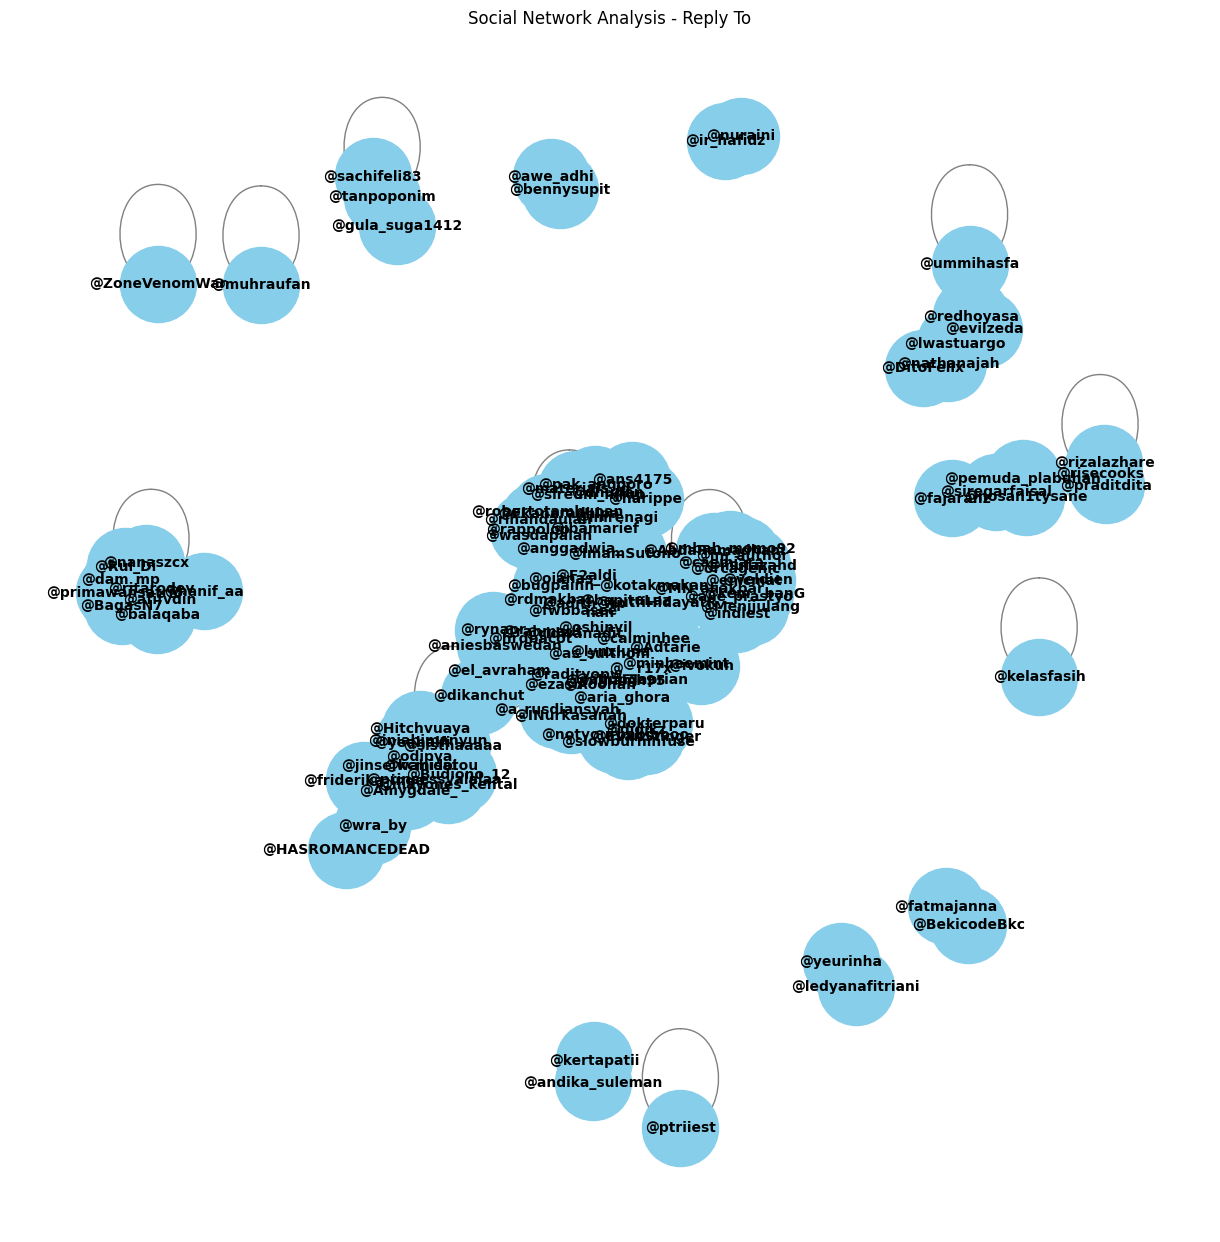

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Filter data yang berisi reply-to
reply_data = combined_data_apify_new[~combined_data_apify_new['replyToTweet/username'].isna()]

# Membuat jaringan reply antara 'username' dan 'replyToTweet/username'
G = nx.from_pandas_edgelist(reply_data, source='username', target='replyToTweet/username')

# Menggambar jaringan
plt.figure(figsize=(12, 12))
nx.draw(G, with_labels=True, node_size=3000, node_color='skyblue', font_size=10, font_weight="bold", edge_color='gray')
plt.title('Social Network Analysis - Reply To')
plt.show()


In [ ]:
reply_data.head()

,avatar,fullname,id,images/0,images/1,images/2,images/3,isMainTweet,isPinned,isQuote,...,user/userFullName,user/username,user/verified,user/website,username,verified,links/3,links/4,links/5,replyingTo/2
7,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850512214031269916,NaN,NaN,NaN,NaN,True,False,True,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
8,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850531828563841132,NaN,NaN,NaN,NaN,True,False,True,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
9,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850493535080022339,NaN,NaN,NaN,NaN,False,False,False,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
10,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850493429484265802,NaN,NaN,NaN,NaN,False,False,False,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
11,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850496557482909989,NaN,NaN,NaN,NaN,False,False,True,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN


In [ ]:
reply_data

,avatar,fullname,id,images/0,images/1,images/2,images/3,isMainTweet,isPinned,isQuote,...,user/userFullName,user/username,user/verified,user/website,username,verified,links/3,links/4,links/5,replyingTo/2
7,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850512214031269916,NaN,NaN,NaN,NaN,True,False,True,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
8,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850531828563841132,NaN,NaN,NaN,NaN,True,False,True,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
9,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850493535080022339,NaN,NaN,NaN,NaN,False,False,False,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
10,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850493429484265802,NaN,NaN,NaN,NaN,False,False,False,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
11,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Sistha,1850496557482909989,NaN,NaN,NaN,NaN,False,False,True,...,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,@sisthaaaaa,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Adith W. Pradipta 🇵🇸,1739464358722445514,NaN,NaN,NaN,NaN,False,False,False,...,Adith W. Pradipta 🇵🇸,@adith_wp,False,adith.vercel.app/,@adith_wp,False,NaN,NaN,NaN,NaN
628,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,r17𝕏,1707669675377926174,NaN,NaN,NaN,NaN,False,False,False,...,r17𝕏,@__r17x,False,evlfctry.pro/rin,@__r17x,False,NaN,NaN,NaN,NaN
638,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Noor✨,1698966071234191824,NaN,NaN,NaN,NaN,False,False,False,...,Noor✨,@lynxluna,True,sysprog.enabler.sh/,@lynxluna,True,NaN,NaN,NaN,NaN
644,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Rahmaut | 🇵🇸,1741156797296357676,NaN,NaN,NaN,NaN,False,False,False,...,Rahmaut | 🇵🇸,@rahmaut,False,suarise.com/a11yID,@rahmaut,False,NaN,NaN,NaN,NaN


In [ ]:
# Menghitung degree centrality
degree_centrality = nx.degree_centrality(G)

# Menampilkan pengguna dengan degree centrality tertinggi
sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]


[('@MN_aliakbar', 0.13559322033898305),
 ('@sisthaaaaa', 0.11016949152542373),
 ('@adith_wp', 0.1016949152542373),
 (nan, 0.09322033898305085),
 ('@lynxluna', 0.09322033898305085),
 ('@aria_ghora', 0.09322033898305085),
 ('@ritarodev', 0.0847457627118644),
 ('@anggadwia_', 0.0847457627118644),
 ('@bepituLaz', 0.0423728813559322),
 ('@ibamarief', 0.0423728813559322)]

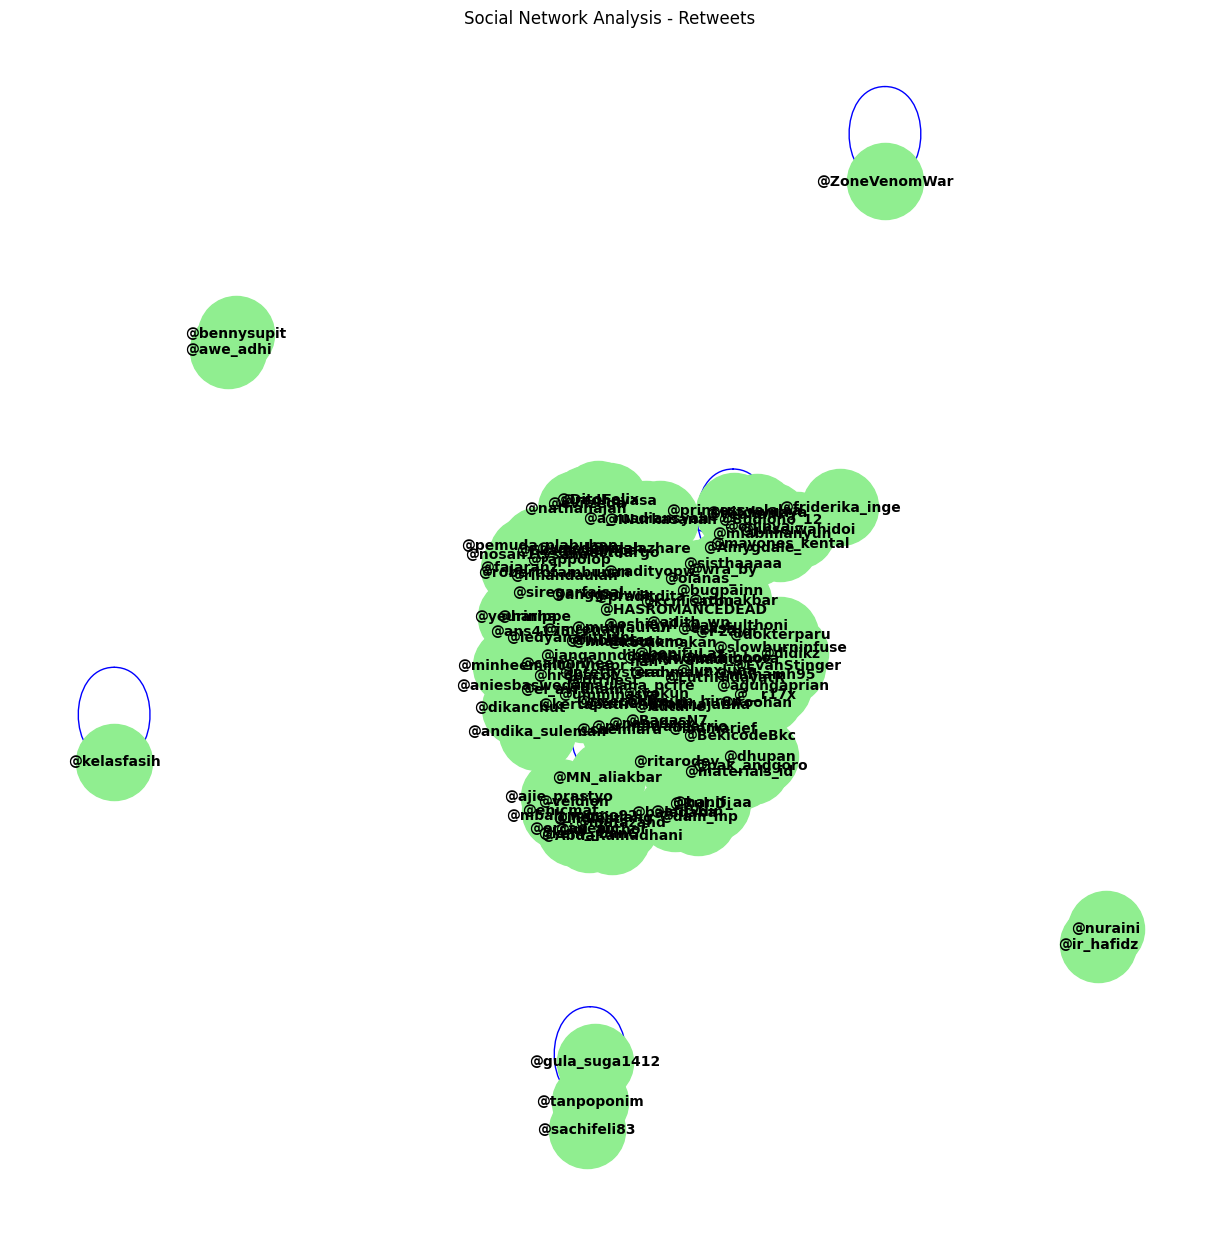

In [ ]:
# Membuat jaringan retweet antara 'username' dan 'retweeted_from'
retweet_data = combined_data_apify_new[~combined_data_apify_new['isRetweet'].isna()]

# Membuat jaringan berdasarkan retweet
G_retweet = nx.from_pandas_edgelist(retweet_data, source='username', target='replyToTweet/username')

# Menggambar jaringan retweet
plt.figure(figsize=(12, 12))
nx.draw(G_retweet, with_labels=True, node_size=3000, node_color='lightgreen', font_size=10, font_weight="bold", edge_color='blue')
plt.title('Social Network Analysis - Retweets')
plt.show()


In [ ]:
pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.2 MB/s eta 0:00:00


In [ ]:
combined_data_apify_new

# Graph SNA manusia setengah chi2

In [ ]:
G = nx.from_pandas_edgelist(reply_data, source='username', target='replyToTweet/username')

In [ ]:
import networkx as nx
my_graph = nx.from_pandas_edgelist(reply_data, source ="username", target = "replyToTweet/username")

In [ ]:
nx.info(my_graph)

AttributeError: module 'networkx' has no attribute 'info'

In [ ]:
import networkx as nx
# Print specific graph attributes as desired
print("Number of nodes:", my_graph.number_of_nodes())
print("Number of edges:", my_graph.number_of_edges())

# Add more attribute prints for other info as needed.

Number of nodes: 119
Number of edges: 125


In [ ]:
my_graph.nodes()

NodeView(('@sisthaaaaa', '@yeahalfi', '@Hitchvuaya', '@kcmisatou', '@MN_aliakbar', '@HASROMANCEDEAD', '@wra_by', '@kertapatii', '@andika_suleman', '@iniabimanyun', '@Amygdale_', '@odipya', '@princessyalalaa', '@mayones_kental', '@ajie_prastyo', '@Menjjulang', '@kem__banG', '@AbdaRamadhani', '@Adtarie', '@mbah_momo92', '@orcagenic', '@indlest', '@ini_author', '@veldien', '@mufazahd', '@enicmat', '@caemiara', '@hrdbacot', '@aniesbaswedan', '@rynapr', '@kelasfasih', '@ptriiest', '@ritarodev', '@primawansatrio', '@adith_wp', '@rdmakbar', '@siregarfaisal', '@nosan1tysane', '@fajaranz', '@pemuda_plabuhan', '@nanaszcx', '@dam_mp', '@hanif_aa', nan, '@fwbbasee', '@lynxluna', '@ridwanadit', '@as_sulthoni', '@bugpainn', '@tanpoponim', '@gula_suga1412', '@balaqaba', '@afifvdin', '@ummihasfa', '@BagasN7', '@calminhee', '@minheemint', '@sachifeli83', '@yeurinha', '@ledyanafitriani', '@Rul_Di', '@bepituLaz', '@ZoneVenomWar', '@awe_adhi', '@bennysupit', '@anggadwia_', '@robertotambunan', '@ezash', '@

In [ ]:
my_graph.edges()

EdgeView([('@sisthaaaaa', '@sisthaaaaa'), ('@sisthaaaaa', '@yeahalfi'), ('@sisthaaaaa', '@Hitchvuaya'), ('@sisthaaaaa', '@kcmisatou'), ('@sisthaaaaa', '@iniabimanyun'), ('@sisthaaaaa', '@Amygdale_'), ('@sisthaaaaa', '@odipya'), ('@sisthaaaaa', '@princessyalalaa'), ('@sisthaaaaa', '@mayones_kental'), ('@sisthaaaaa', '@ezash'), ('@sisthaaaaa', '@jinseiwahidoi'), ('@sisthaaaaa', '@Budiono_12'), ('@MN_aliakbar', '@MN_aliakbar'), ('@MN_aliakbar', '@ajie_prastyo'), ('@MN_aliakbar', '@Menjjulang'), ('@MN_aliakbar', '@kem__banG'), ('@MN_aliakbar', '@AbdaRamadhani'), ('@MN_aliakbar', '@Adtarie'), ('@MN_aliakbar', '@mbah_momo92'), ('@MN_aliakbar', '@orcagenic'), ('@MN_aliakbar', '@indlest'), ('@MN_aliakbar', '@ini_author'), ('@MN_aliakbar', '@veldien'), ('@MN_aliakbar', '@mufazahd'), ('@MN_aliakbar', '@enicmat'), ('@MN_aliakbar', '@caemiara'), ('@MN_aliakbar', nan), ('@HASROMANCEDEAD', '@wra_by'), ('@wra_by', '@Amygdale_'), ('@kertapatii', '@andika_suleman'), ('@Adtarie', '@lynxluna'), ('@Adtari

## Visualisasi

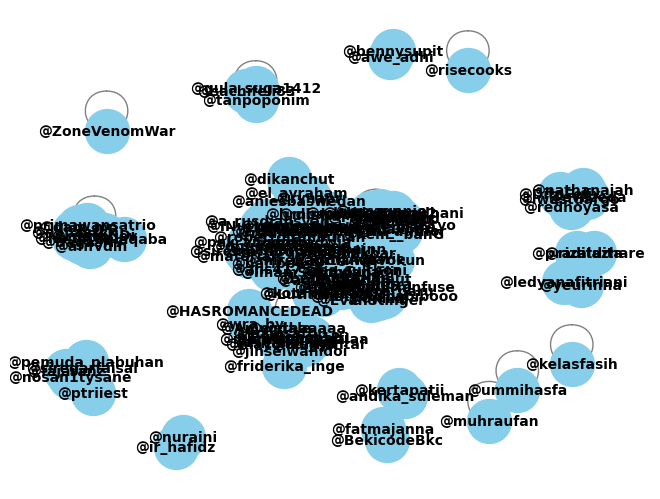

In [ ]:
nx.draw(my_graph, with_labels=True, node_size=1000, node_color='skyblue', font_size=10, font_weight="bold", edge_color='gray')

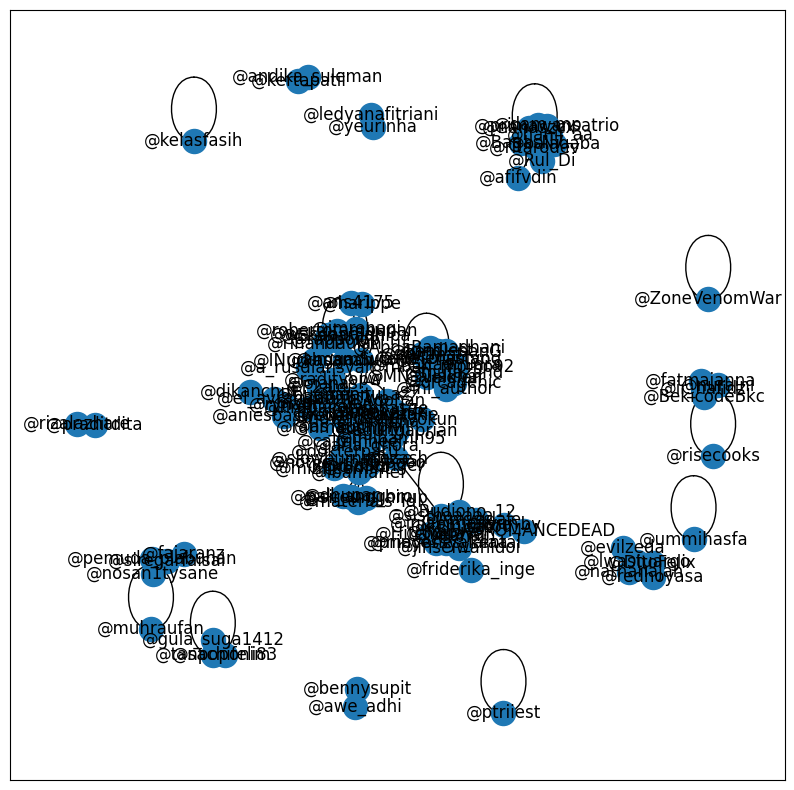

In [ ]:
plt.figure(figsize = (10, 10))
nx.draw_networkx(my_graph)
plt.show()

In [ ]:
#only select column username and replyToTweet/username
reply_data_gephy = combined_data_apify_new[['username', 'replyToTweet/username']]
# rename username to source replyToTweet/username to target
reply_data_gephy = reply_data_gephy.rename(columns={'username': 'source', 'replyToTweet/username': 'target'})
reply_data_gephy.to_csv('reply_data_gephy.csv', index=False)

In [ ]:
retweet_data = combined_data_apify_new[~combined_data_apify_new['isRetweet'].isna()]
#retweeted_from
# Membuat jaringan berdasarkan retweet
#G_retweet = nx.from_pandas_edgelist(retweet_data, source='username', target='replyToTweet/username')
#retweet_data_gephy = retweet_data_gephy.rename(columns={'username': 'source', 'replyToTweet/username': 'target'})


In [ ]:
retweet_data.columns

Index(['avatar', 'fullname', 'id', 'images/0', 'images/1', 'images/2',
       'images/3', 'isMainTweet', 'isPinned', 'isQuote', 'isReply',
       'isRetweet', 'isRootThread', 'likes', 'links/0', 'links/1', 'links/2',
       'mainTweetUrl', 'quotedTweet/avatar', 'quotedTweet/fullname',
       'quotedTweet/images/0', 'quotedTweet/images/1', 'quotedTweet/images/2',
       'quotedTweet/images/3', 'quotedTweet/links/0', 'quotedTweet/links/1',
       'quotedTweet/links/2', 'quotedTweet/links/3', 'quotedTweet/links/4',
       'quotedTweet/links/5', 'quotedTweet/text', 'quotedTweet/timestamp',
       'quotedTweet/url', 'quotedTweet/username', 'quotes', 'replies',
       'replyToTweet/avatar', 'replyToTweet/fullname', 'replyToTweet/id',
       'replyToTweet/images/0', 'replyToTweet/images/1',
       'replyToTweet/images/2', 'replyToTweet/images/3',
       'replyToTweet/isMainTweet', 'replyToTweet/isPinned',
       'replyToTweet/isQuote', 'replyToTweet/isRetweet', 'replyToTweet/likes',
       'r

In [ ]:
#display all column
pd.set_option('display.max_columns', None)
#display max values
pd.set_option('display.max_rows', None)
retweet_data.head()


,avatar,fullname,id,images/0,images/1,images/2,images/3,isMainTweet,isPinned,isQuote,isReply,isRetweet,isRootThread,likes,links/0,links/1,links/2,mainTweetUrl,quotedTweet/avatar,quotedTweet/fullname,quotedTweet/images/0,quotedTweet/images/1,quotedTweet/images/2,quotedTweet/images/3,quotedTweet/links/0,quotedTweet/links/1,quotedTweet/links/2,quotedTweet/links/3,quotedTweet/links/4,quotedTweet/links/5,quotedTweet/text,quotedTweet/timestamp,quotedTweet/url,quotedTweet/username,quotes,replies,replyToTweet/avatar,replyToTweet/fullname,replyToTweet/id,replyToTweet/images/0,replyToTweet/images/1,replyToTweet/images/2,replyToTweet/images/3,replyToTweet/isMainTweet,replyToTweet/isPinned,replyToTweet/isQuote,replyToTweet/isRetweet,replyToTweet/likes,replyToTweet/links/0,replyToTweet/links/1,replyToTweet/mainTweetUrl,replyToTweet/quotedTweet/avatar,replyToTweet/quotedTweet/fullname,replyToTweet/quotedTweet/images/0,replyToTweet/quotedTweet/images/1,replyToTweet/quotedTweet/images/2,replyToTweet/quotedTweet/images/3,replyToTweet/quotedTweet/links/0,replyToTweet/quotedTweet/links/1,replyToTweet/quotedTweet/text,replyToTweet/quotedTweet/timestamp,replyToTweet/quotedTweet/url,replyToTweet/quotedTweet/username,replyToTweet/quotes,replyToTweet/replies,replyToTweet/retweets,replyToTweet/searchQuery,replyToTweet/text,replyToTweet/timestamp,replyToTweet/url,replyToTweet/username,replyToTweet/verified,replyingTo/0,replyingTo/1,retweets,searchQuery,text,timestamp,url,user/avatar,user/description,user/joinDate,user/location,user/totalFollowers,user/totalFollowing,user/totalLikes,user/totalTweets,user/url,user/userFullName,user/username,user/verified,user/website,username,verified,links/3,links/4,links/5,replyingTo/2
0,NaN,NaN,1850490485351256364,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,NaN,706,https://twitter.com/search?q=%23KaburAjaDulu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,#kaburajadulu,Mungkin bisa jadi pertimbangan buat temen-teme...,2024-10-27T10:51:00.000Z,https://twitter.com/sisthaaaaa/status/18504904...,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Indonesian lives in Japan｜iPhone photography｜a...,2009-07-31T03:49:00.000Z,"Tokyo-to, Japan",26099,515,2494,55856,https://twitter.com//sisthaaaaa,Sistha,@sisthaaaaa,False,instagram.com/wasisthaweesen…,NaN,False,NaN,NaN,NaN,NaN
1,NaN,NaN,1834505771159056640,https://cdn.xcancel.comhttps://pbs.twimg.com/m...,NaN,NaN,NaN,NaN,NaN,False,False,True,NaN,7373,https://twitter.com/search?q=%23kaburAjaDulu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1278,#kaburajadulu,Kemaren banyak yg nanya gmana caranya dpt kerj...,2024-09-13T08:13:00.000Z,https://twitter.com/MN_aliakbar/status/1834505...,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Tukang minyak di negeri kutub utara.\nIG: mn_a...,2010-09-15T14:08:00.000Z,"Trondheim, Norway",4924,573,4283,31861,https://twitter.com//MN_aliakbar,MN Ali Akbar 🇮🇩🇭🇺🇳🇴,@MN_aliakbar,False,linkedin.com/in/muhammad-nur…,NaN,False,NaN,NaN,NaN,NaN
2,NaN,NaN,1850545176000782613,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,NaN,1,https://twitter.com/search?q=%23KaburAjaDulu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/MN_aliakbar,NaN,0,#kaburajadulu,Semoga bisa secepatnya jadi bagian #KaburAjaDu...,2024-10-27T14:28:00.000Z,https://twitter.com/thundervsearth/status/1850...,https://cdn.xcancel.comhttps://pbs.twimg.com/p...,Yang punya akun lagi sibuk mencari wangsit di ...,2011-10-02T08:23:00.000Z,INA,438,877,3067,11332,https://